# Statistics for Michel electron candidate (PDHD MC production New202508)

### Created by Shu, 202508---

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


coinNum = [] # wvf coin num--
coinTrueE = [] # energy of candidates---
coinPDG = []

file_list = [
    "./pdsStat_20250828/print_wvfCoin_count20250828.txt"
]
for fname in file_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = int(parts[1].strip())
                        coinNum.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")


coinTrueE_file_paths = [
    './pdsStat_20250828/print_trueE20250828.txt'
]
for file_path in coinTrueE_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                coinTrueE.append(float(value))


coinPDG_file_paths = [
    './pdsStat_20250828/print_truePDG20250828.txt'
]
for file_path in coinPDG_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                coinPDG.append(float(value))




print("Track candidates (TPC cut)  : 2706")
print("Track candidates with NO wvf: 406")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * (88+95))



print("\nLength of track coinTrueE: ", len(coinTrueE))
print("Length of track coinPDG  : ", len(coinPDG))


Track candidates (TPC cut)  : 2706
Track candidates with NO wvf: 406
Number of track candidates  : 2309

Length of track coinTrueE:  2309
Length of track coinPDG  :  2309


Purity of coinNum:  2098 / 2309 (90.86%)
Michel e:  367 / 2098 (17.49%)
Michel p:  1731 / 2098 (82.51%)

Candidates with #opWvf>=4:  1953 / 2309 (84.58%)
Purity:  1764 / 1953 (90.32%)


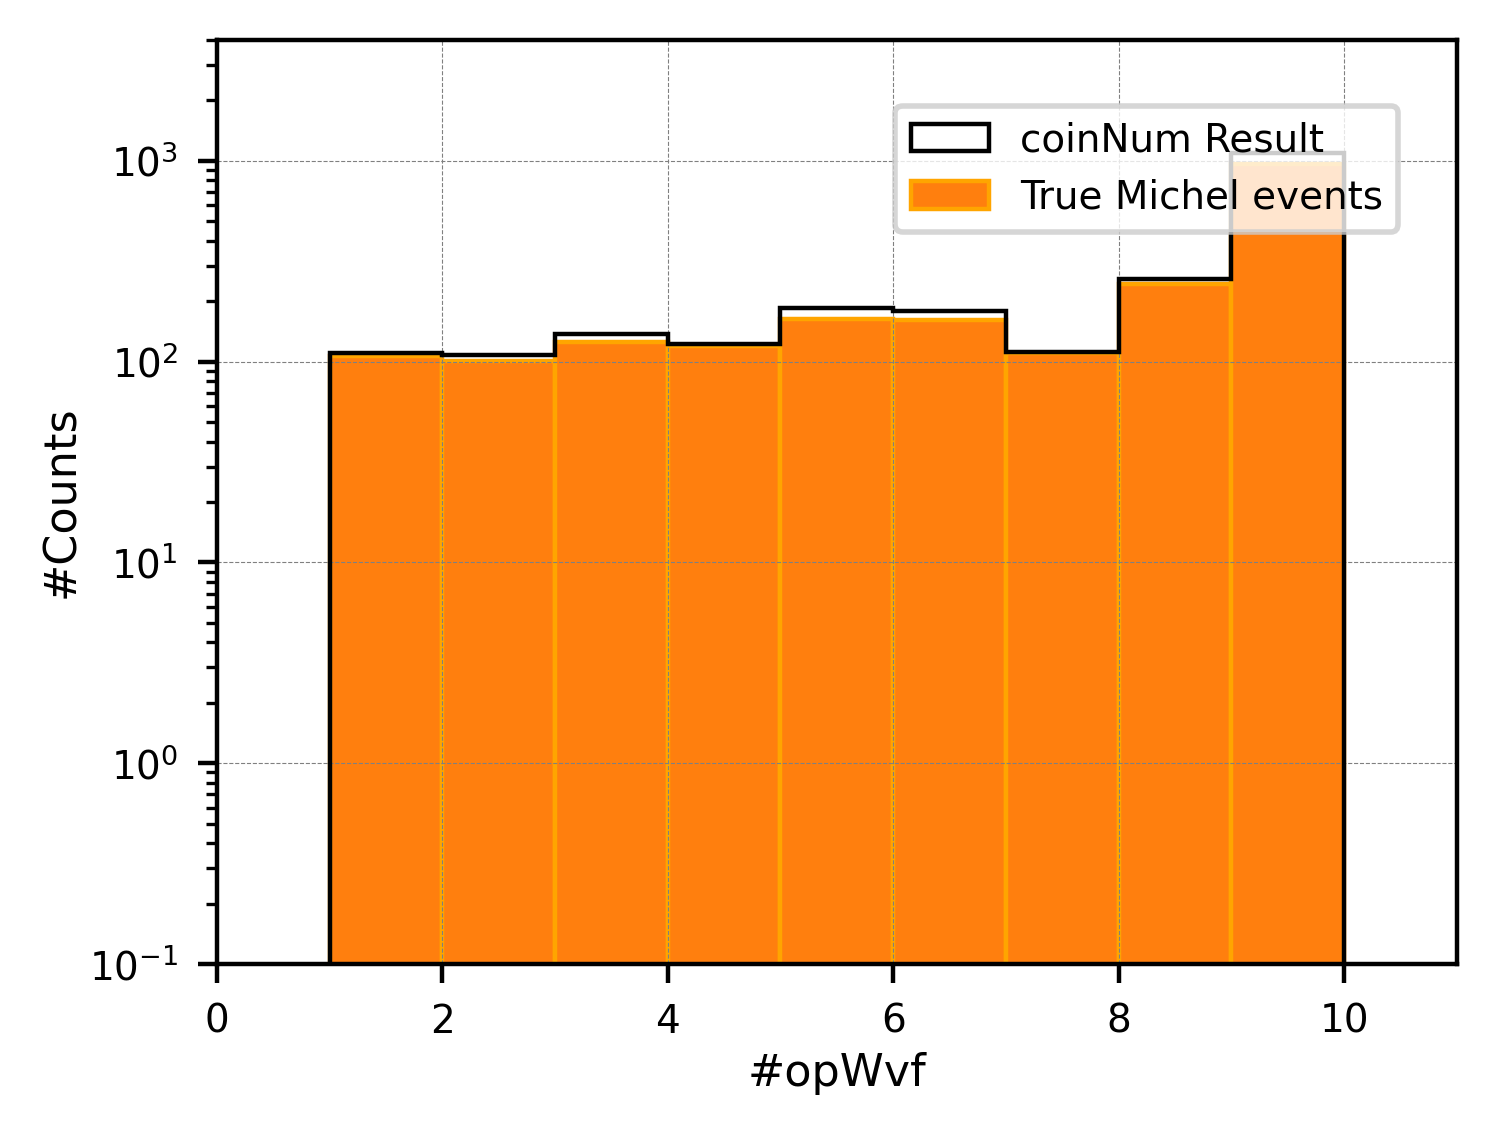

<Figure size 1600x1200 with 0 Axes>

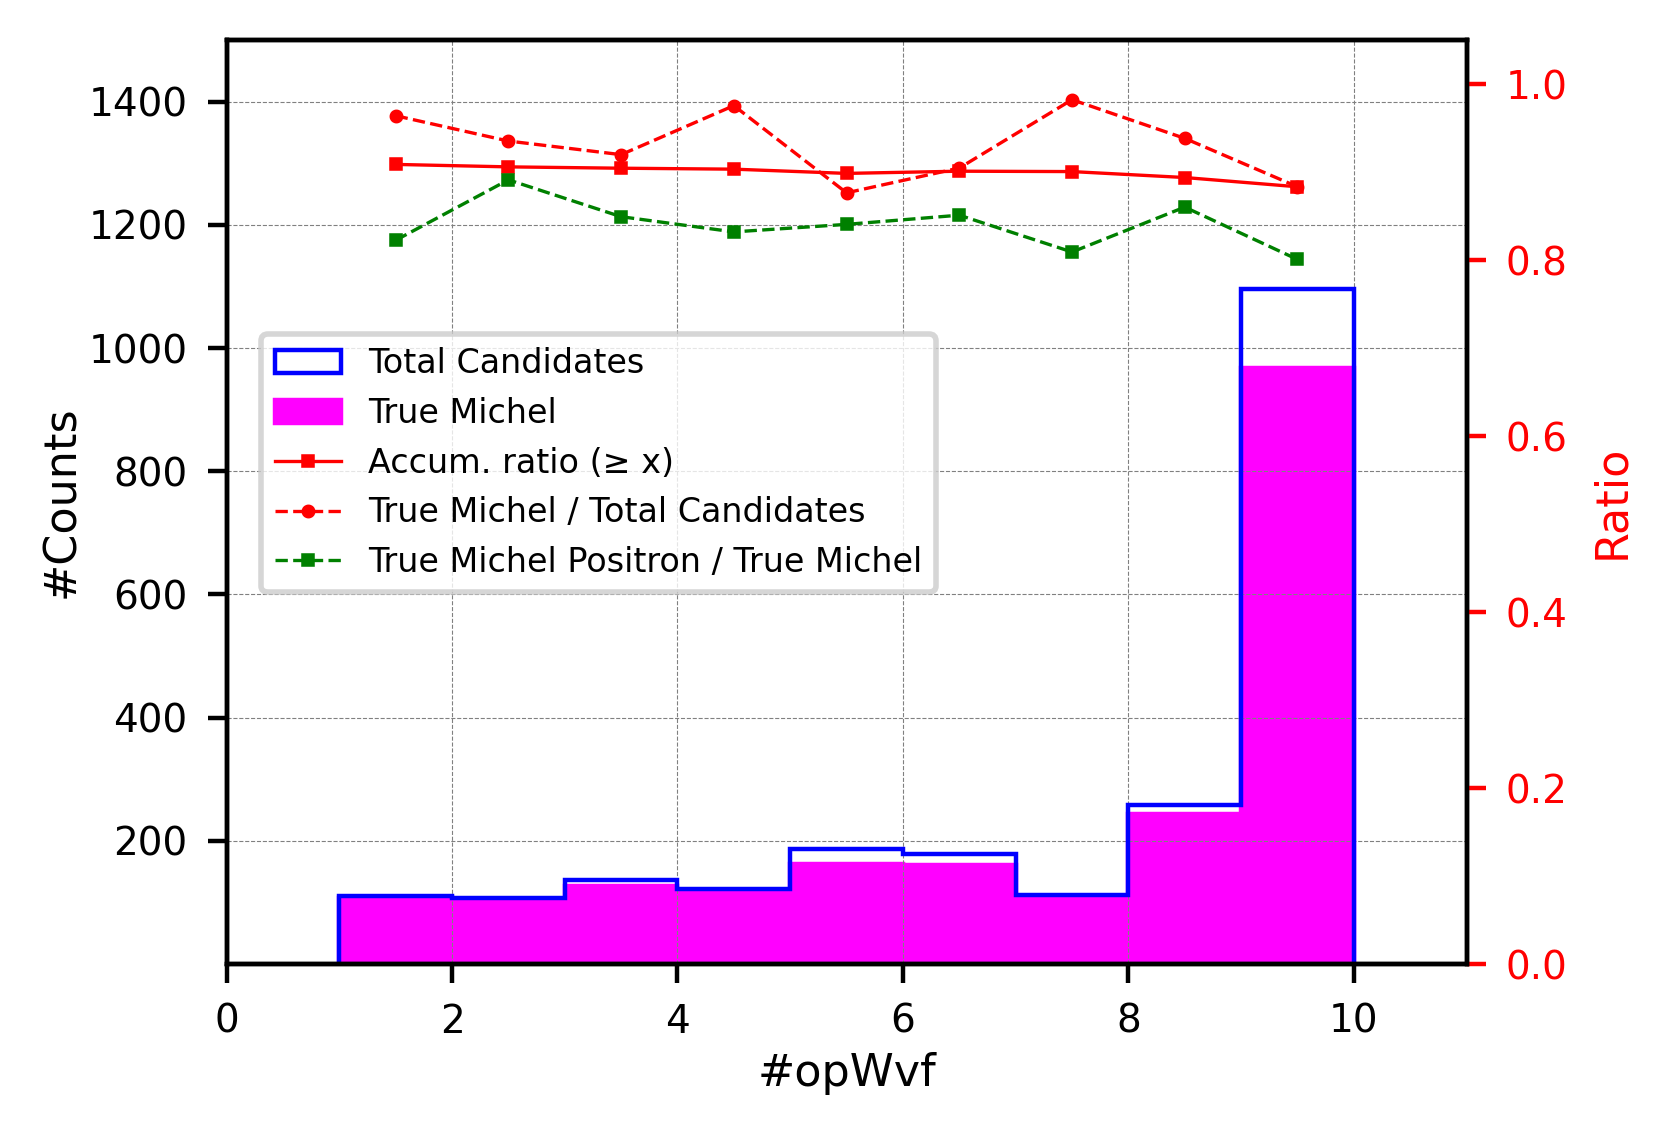

In [12]:

#Extract coinNum with trueE:===========================
coinNum_trueE = []
coinNum_trueE_e = [] #Michel electron
coinNum_trueE_p = [] #Michel positron
for i in range(0, len(coinTrueE)):
    count = coinNum[i]
    e = coinTrueE[i]
    pdg = coinPDG[i]

    if e > 0:
        coinNum_trueE.append(count)
        if pdg == 11:
            coinNum_trueE_e.append(count)
        if pdg == -11:
            coinNum_trueE_p.append(count)

print("Purity of coinNum: ", len(coinNum_trueE), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_trueE)/len(coinNum)*100))
print("Michel e: ", len(coinNum_trueE_e), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_e)/len(coinNum_trueE)*100))
print("Michel p: ", len(coinNum_trueE_p), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_p)/len(coinNum_trueE)*100))





#Apply preliminary cut #opWvf >=4:=====================
coinNum_cut5 = []
coinNum_trueE_cut5 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]
    trueE = coinTrueE[i]

    if coin >=4:
        coinNum_cut5.append(coin)
    
        if trueE > 0:
            coinNum_trueE_cut5.append(trueE)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut5), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut5)/len(coinNum)*100))
print("Purity: ", len(coinNum_trueE_cut5), "/", len(coinNum_cut5), "({:.2f}%)".format(len(coinNum_trueE_cut5)/len(coinNum_cut5)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.plot([5, 5], [0, 1200], color="black", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')
plt.hist(coinNum_trueE, bins=bins, range=(range_min, range_max), edgecolor='orange', 
         histtype='bar', linewidth=0.8, label="True Michel events")



plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
#plt.ylim(0, 50)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 4000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 1
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(coinNum, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(coinNum_trueE, bins=bins, range=(range_min, range_max))
hist_trueP, _ = np.histogram(coinNum_trueE_p, bins=bins, range=(range_min, range_max))#True positron

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', color='magenta', histtype='bar', 
         linewidth=0.8, label="True Michel")
#ax1.hist(bin_centers, bins=bins, weights=hist_trueP, edgecolor='green', color='green', histtype='bar', 
#         linewidth=0.8, label="True Michel Positron")


#ax1.plot([4, 4], [0, 1400], color="blue", linewidth=0.8, linestyle='-')


ax1.set_xlim(0, 11)
ax1.set_xlabel('#opWvf', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.set_ylim(0.1, 1500)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero

ratio2 = np.divide(hist_trueP, hist_true, out=np.zeros_like(hist_trueP, dtype=float), where=hist_total!=0)  # Avoid division by zero

# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel / Total Candidates")

ax2.plot(bin_centers, ratio2, color='green', marker='s', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel Positron / True Michel")



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0.0, 1.05)

ax2.tick_params(axis='y', labelsize=7, colors='red')



# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.7),
           fontsize=9, ncol=1, prop={'size': 6})



plt.show()



<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4)

In [13]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None
    pdg: Optional[int] = None



def read_colon_file(fname, cast_type=float):
    """Read files formatted as 'path: value' and return a list of values."""
    values = []
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        values.append(cast_type(parts[1].strip()))
                    except ValueError:
                        print(f"Could not convert {parts[1].strip()} in {fname}")
    except FileNotFoundError:
        print(f"File not found: {fname}")
    return values

def read_plain_file(fname, cast_type=float):
    """Read plain text files with one number per line."""
    values = []
    try:
        with open(fname, "r") as file:
            for line in file:
                value = line.strip()
                if value:
                    values.append(cast_type(value))
    except FileNotFoundError:
        print(f"File not found: {fname}")
    return values


muon_time       = read_colon_file("./pdsStat_20250828/muon_time_20250828.txt", int)
michel_time     = read_colon_file("./pdsStat_20250828/michel_time_20250828.txt", int)
muon_intensity  = read_colon_file("./pdsStat_20250828/muon_intensity_20250828.txt", float)
michel_intensity= read_colon_file("./pdsStat_20250828/michel_intensity_20250828.txt", float)

posX            = read_plain_file("./pdsStat_20250828/posX_extract_20250828.txt", float)
posY            = read_plain_file("./pdsStat_20250828/posY_extract_20250828.txt", float)
posZ            = read_plain_file("./pdsStat_20250828/posZ_extract_20250828.txt", float)

energy          = read_plain_file("./pdsStat_20250828/energy_extract_20250828.txt", float)
lifetime        = read_plain_file("./pdsStat_20250828/lifetime_extract_20250828.txt", float)
pdg             = read_plain_file("./pdsStat_20250828/pdg_extract_20250828.txt", int)

print("Single list check:---------------------------------------")
print("muon_time (TPC cut)       :", len(muon_time))
print("michel_time (TPC cut)     :", len(michel_time))
print("muon_intensity (TPC cut)  :", len(muon_intensity))
print("michel_intensity (TPC cut):", len(michel_intensity))
print("posX (TPC cut)            :", len(posX))
print("posY (TPC cut)            :", len(posY))
print("posZ (TPC cut)            :", len(posZ))
print("energy (TPC cut)          :", len(energy))
print("lifetime (TPC cut)        :", len(lifetime))
print("pdg (TPC cut)             :", len(pdg))

print("\nMin[muon_intensity]       : ", np.min(muon_intensity))
print("Min[michel_intensity]     : ", np.min(michel_intensity))
print("Min[michel_time]          : ", np.min(michel_time))




#Very initial dataset------------------------------------
events_veryInitial = []
n_events = min(len(muon_time), len(michel_time), len(muon_intensity),
               len(michel_intensity), len(posX), len(posY), len(posZ),
               len(energy), len(lifetime), len(pdg))

for i in range(n_events):
    ev = PdsEvent(
        muon_time=muon_time[i],
        michel_time=michel_time[i],
        muon_intensity=muon_intensity[i],
        michel_intensity=michel_intensity[i],
        posX=posX[i],
        posY=posY[i],
        posZ=posZ[i],
        energy=energy[i],
        lifetime=lifetime[i],
        pdg=pdg[i]
    )
    events_veryInitial.append(ev)

print("\nVery initial dataset: ", len(events_veryInitial))





#Apply cuts on peak intensities-----------------------------
events_reco_initial = []
events_true_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity
    e = ev.energy

    if muIntensity > 0.3  and miIntensity > -0.1:
        events_reco_initial.append(ev)

        if e > 0:
            events_true_initial.append(ev)

print("\nDataset after initial intensity-cut----------------------")
print("Michel purity (true/reco): ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100)) 







Single list check:---------------------------------------
muon_time (TPC cut)       : 1953
michel_time (TPC cut)     : 1953
muon_intensity (TPC cut)  : 1953
michel_intensity (TPC cut): 1953
posX (TPC cut)            : 1953
posY (TPC cut)            : 1953
posZ (TPC cut)            : 1953
energy (TPC cut)          : 1953
lifetime (TPC cut)        : 1953
pdg (TPC cut)             : 1953

Min[muon_intensity]       :  0.302059
Min[michel_intensity]     :  0.0
Min[michel_time]          :  0

Very initial dataset:  1953

Dataset after initial intensity-cut----------------------
Michel purity (true/reco):  1764 /  1953 (90.32%)


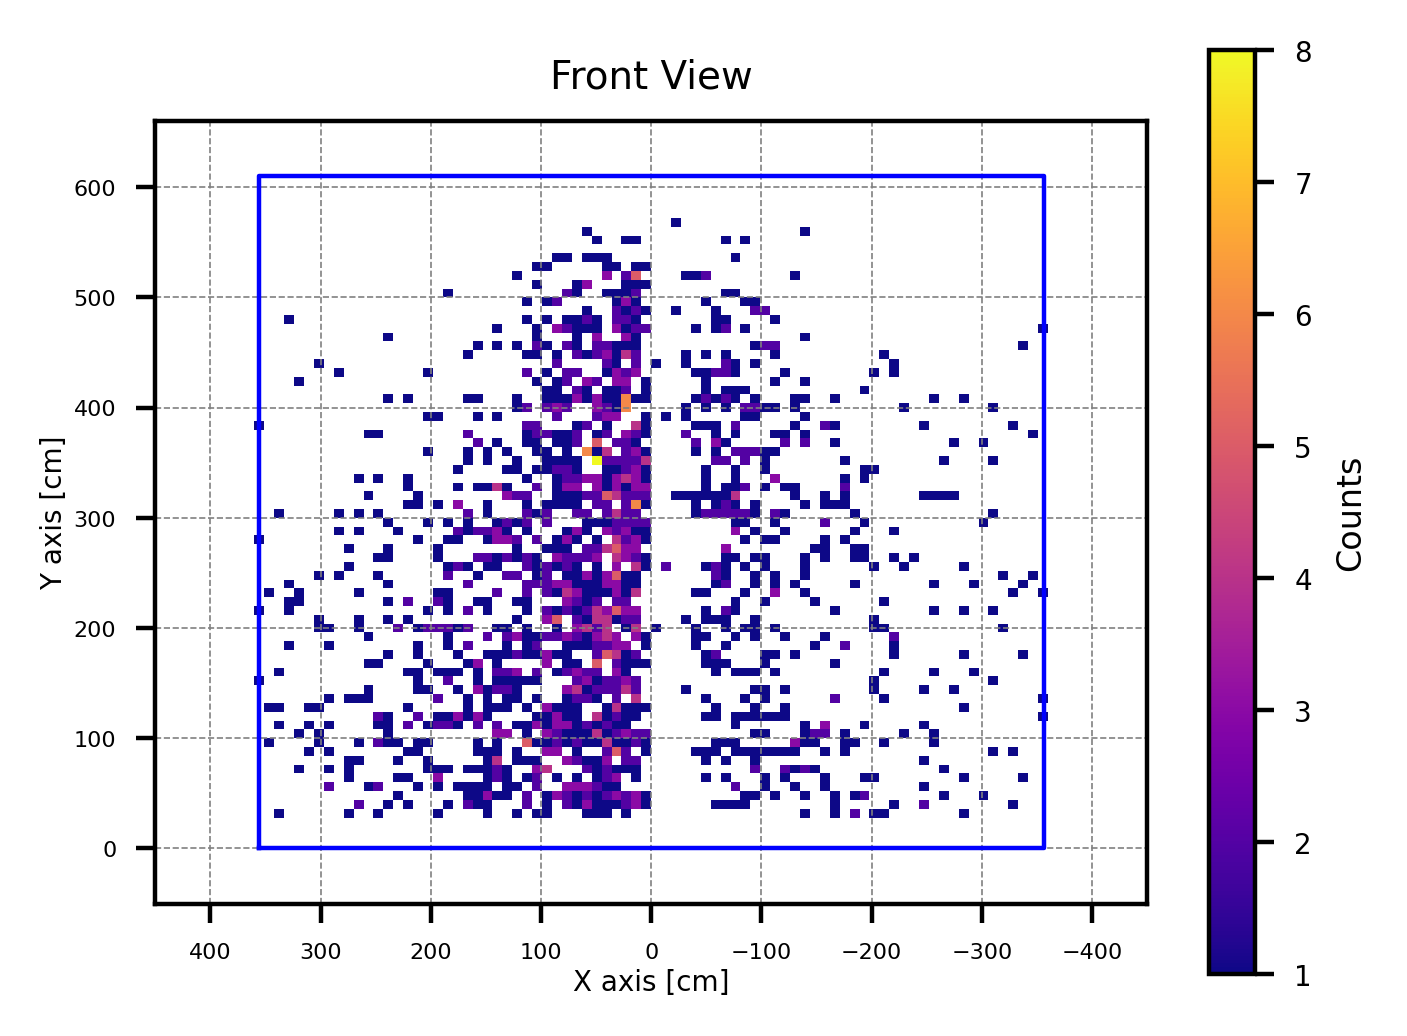

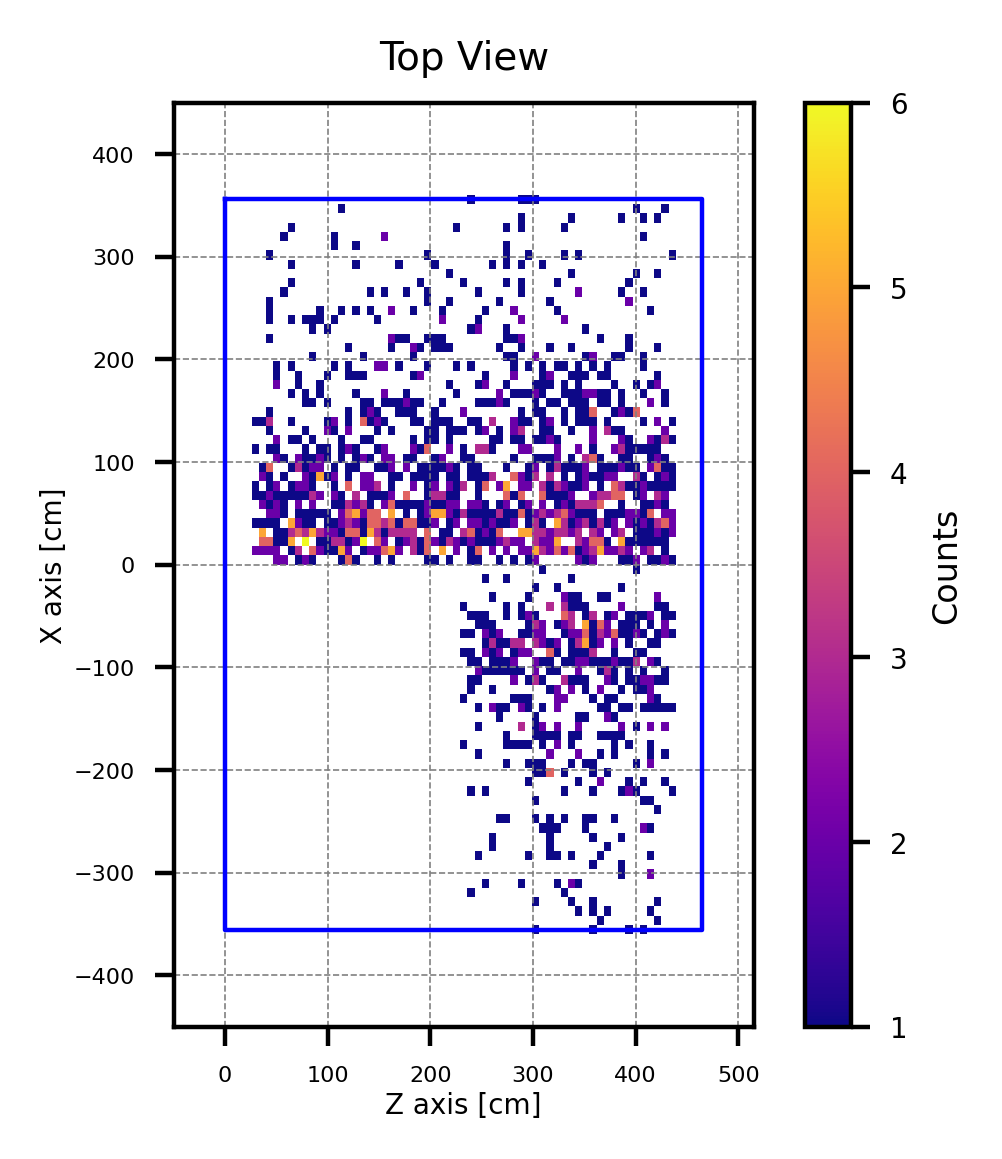


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  479 (24.53%)
# of X >= 0:  1474 (75.47%)

Michel purity:  1764 /  1953 (90.32%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.000
   -345.0 | 0.667
   -335.0 | 0.600
   -325.0 | 1.000
   -315.0 | 1.000
   -305.0 | 0.800
   -295.0 | 1.000
   -285.0 | 1.000
   -275.0 | 0.750
   -265.0 | 0.500
   -255.0 | 0.857
   -245.0 | 0.750
   -235.0 | 1.000
   -225.0 | 1.000
   -215.0 | 0.875
   -205.0 | 1.000
   -195.0 | 0.818
   -185.0 | 0.800
   -175.0 | 0.867
   -165.0 | 0.923
   -155.0 | 0.857
   -145.0 | 0.941
   -135.0 | 0.941
   -125.0 | 0.857
   -115.0 | 0.889
   -105.0 | 1.000
    -95.0 | 0.939
    -85.0 | 0.759
    -75.0 | 0.846
    -65.0 | 0.920
    -55.0 | 0.853
    -45.0 | 0.826
    -35.0 | 1.000
    -25.0 | 1.000
    -15.0 | 1.000
     -5.0 | 1.000
      5.0 | 0.960
     15.0 | 0.954
     25.0 | 0.942
     35.0 | 0.940
     45.0 | 0.904
     55.0 | 0.870
     65.0 | 0.924
     75.0 | 0.9

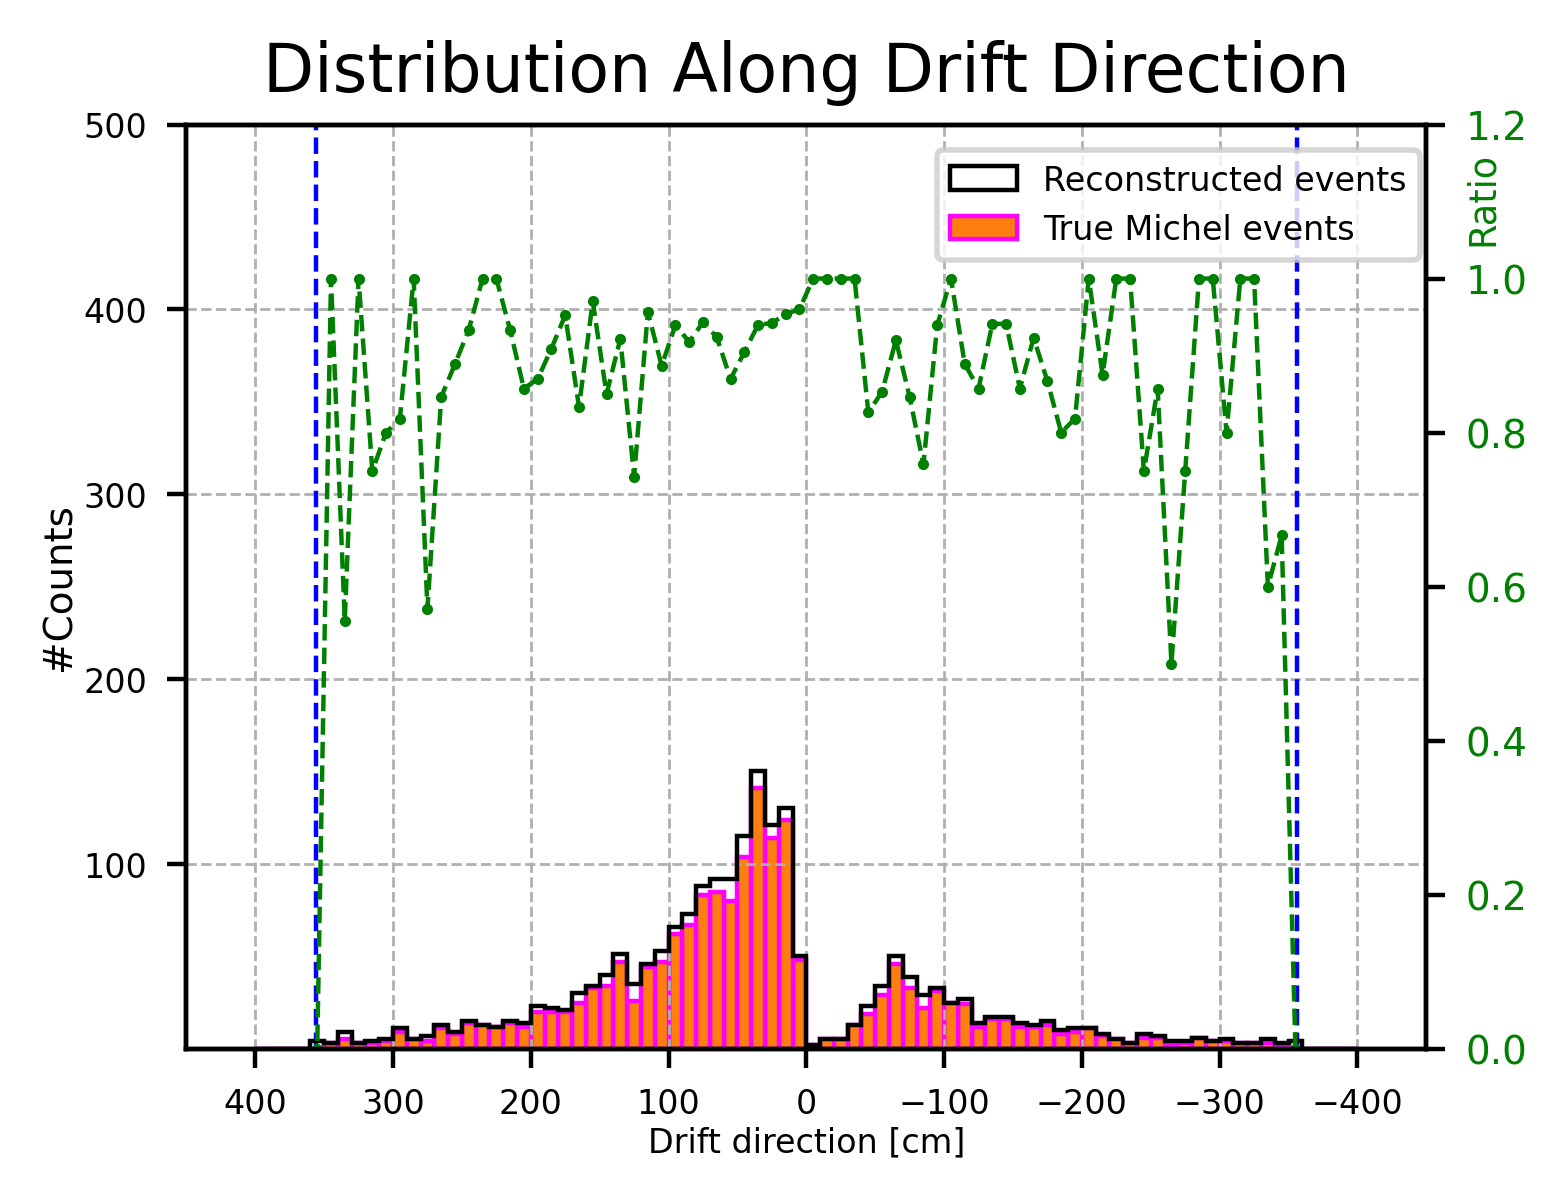

In [14]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]

posX_true = [ev.posX for ev in events_true_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))

print("\nMichel purity: ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100))         



# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(posX, bins=bins)
n_final, _ = np.histogram(posX_true, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='Reconstructed events')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='bar', linewidth=0.8, label='True Michel events')

ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-450, 450)
ax1.set_ylim(0.1, 500)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.invert_xaxis()
#ax1.set_yscale('log')
ax1.tick_params(labelsize=6)

# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o--', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=6.6, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.92)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)

# Final layout
#plt.tight_layout()

plt.title('Distribution Along Drift Direction', fontsize=12)

plt.show()



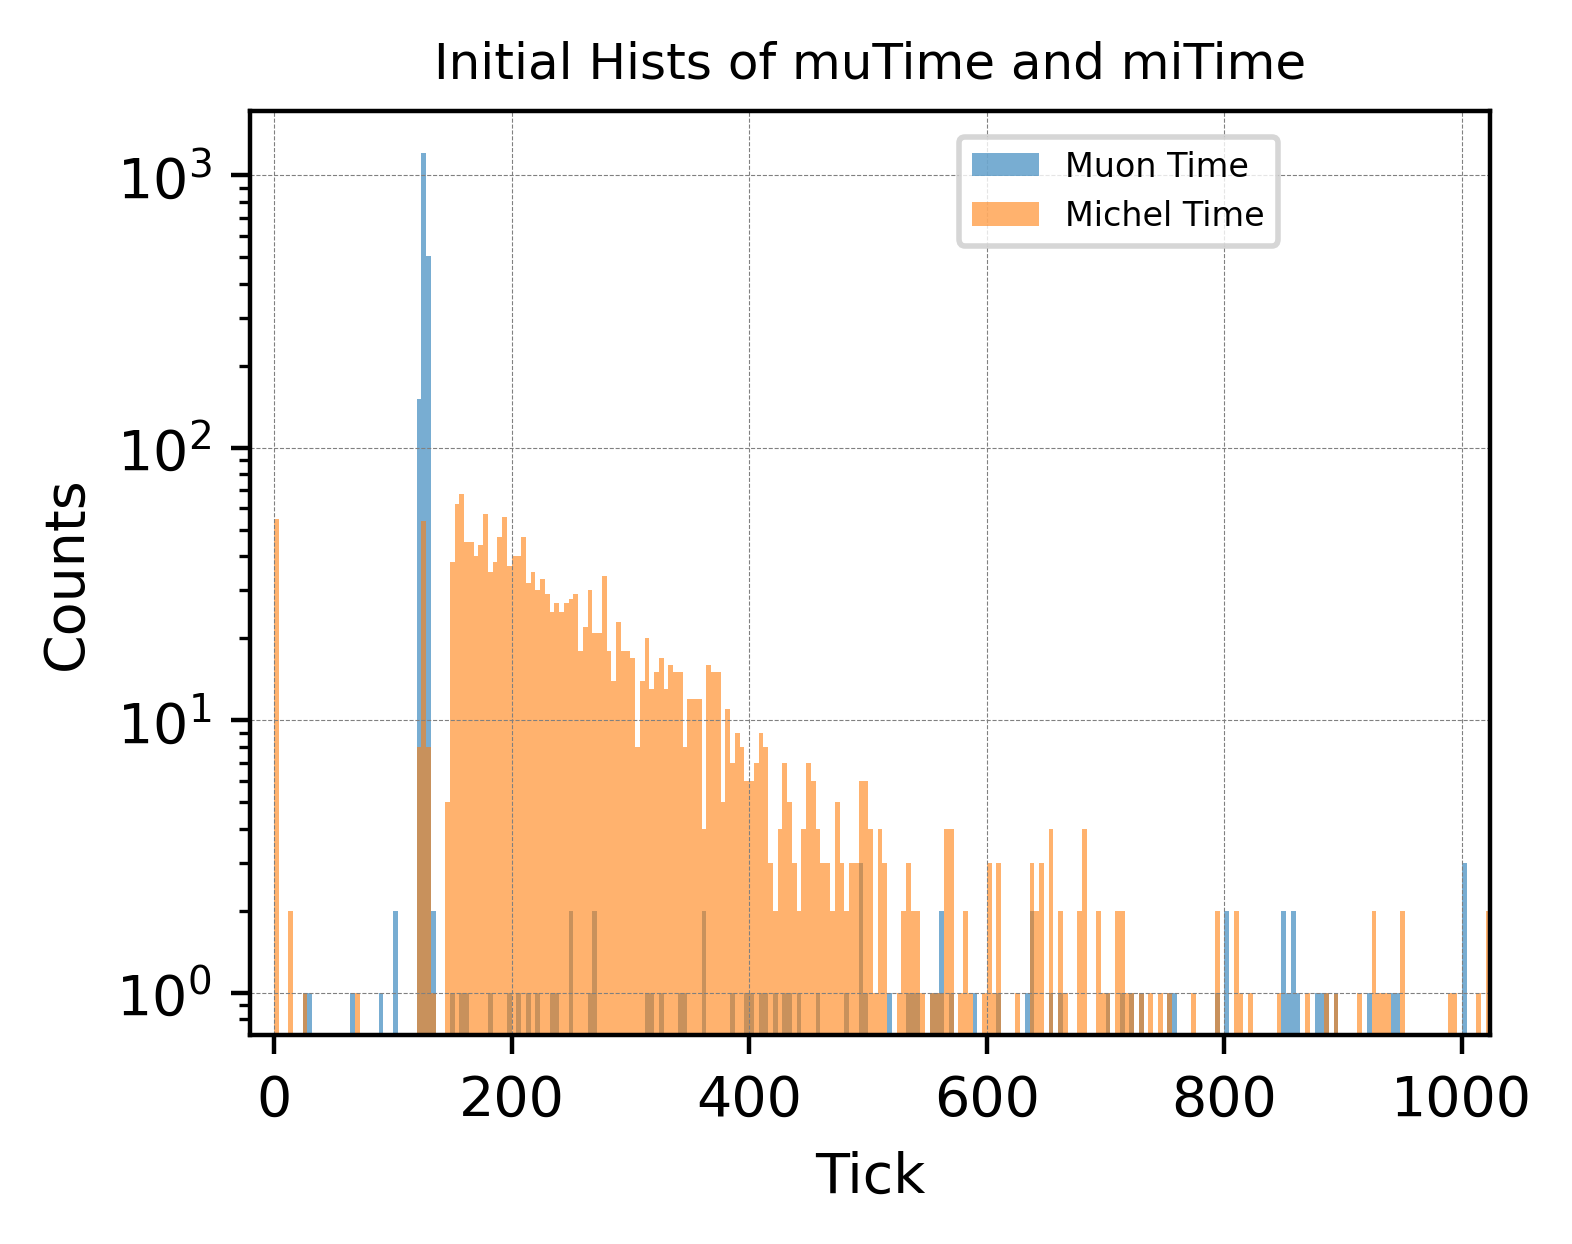

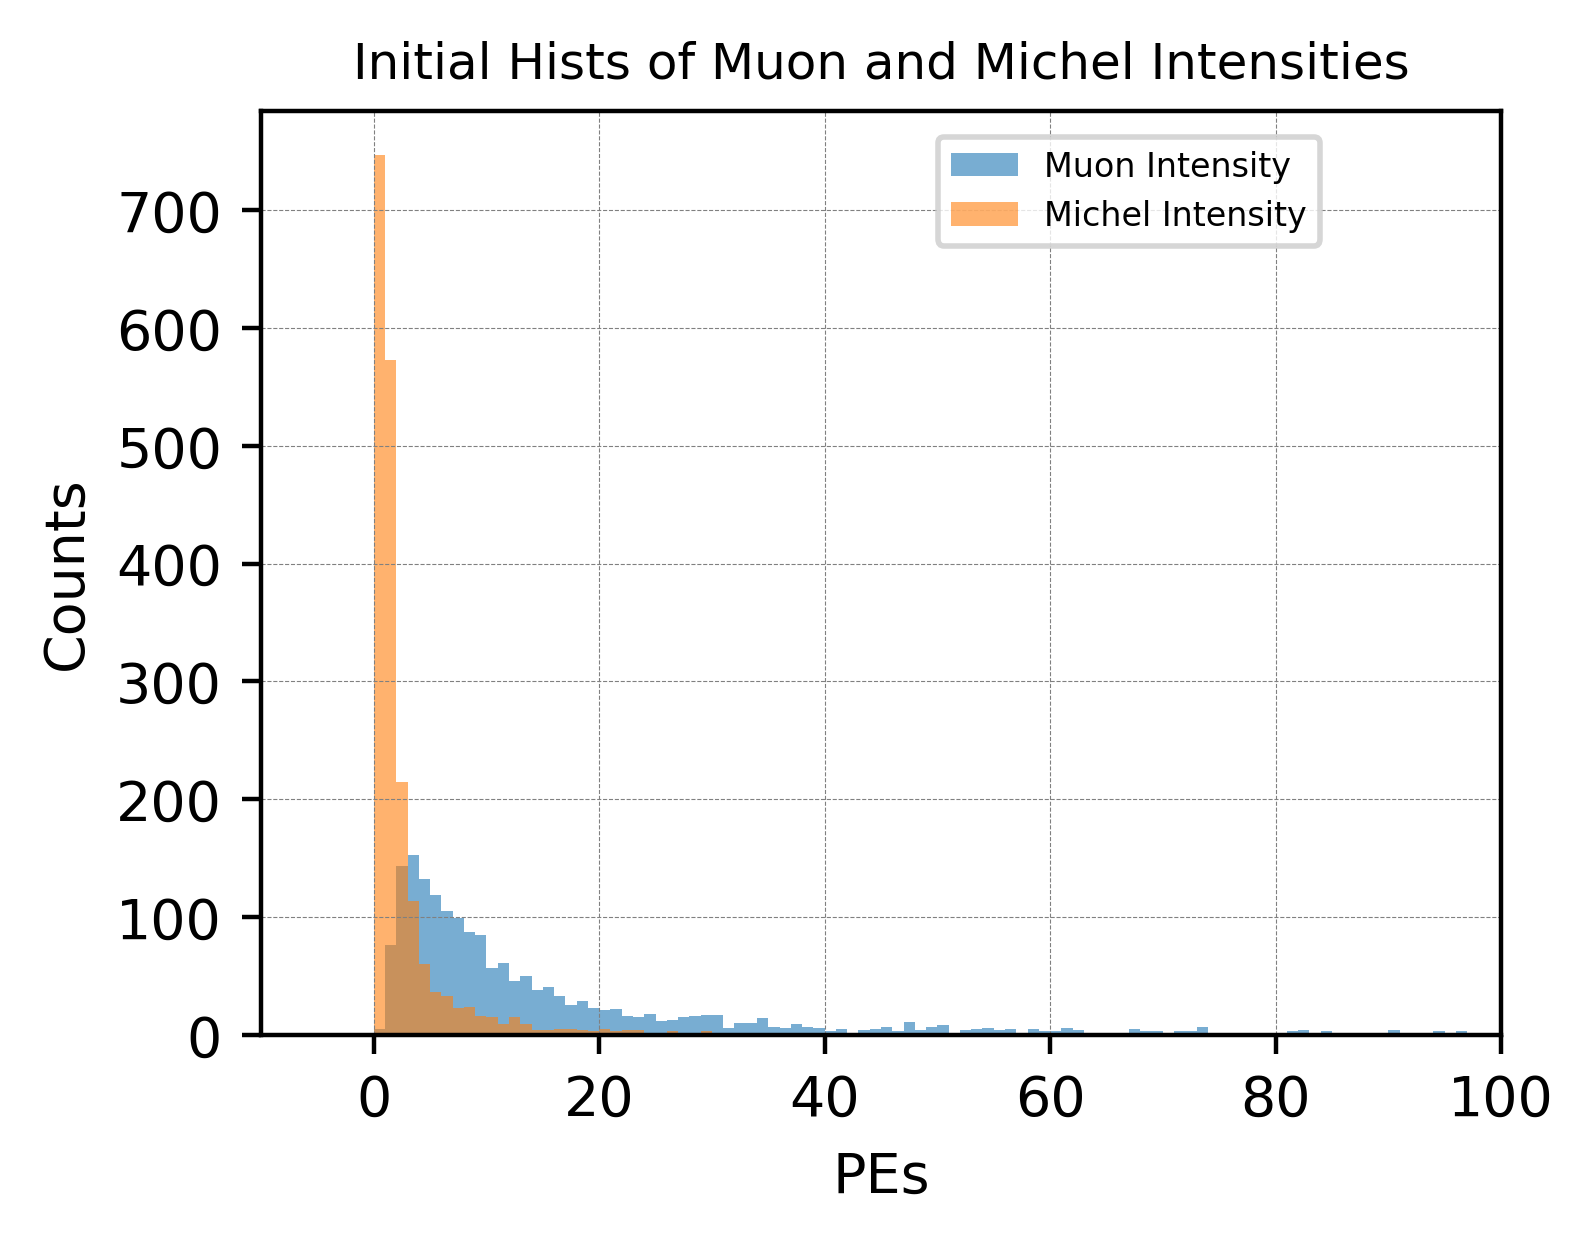

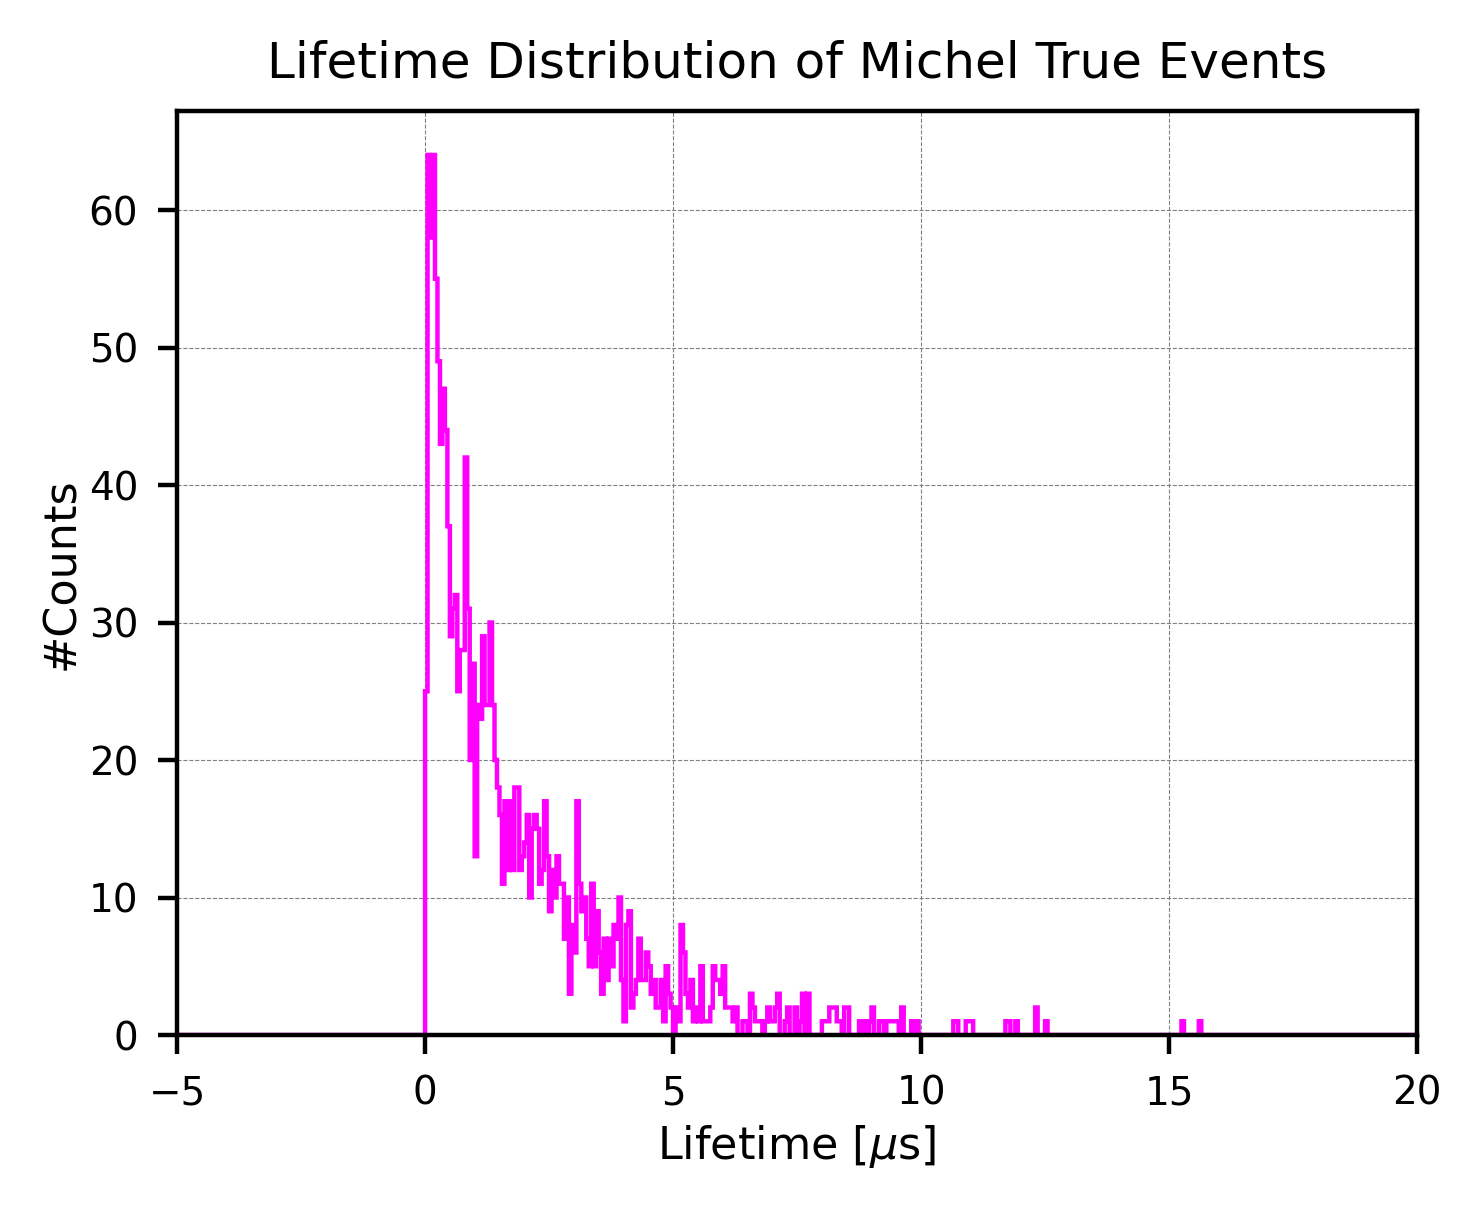

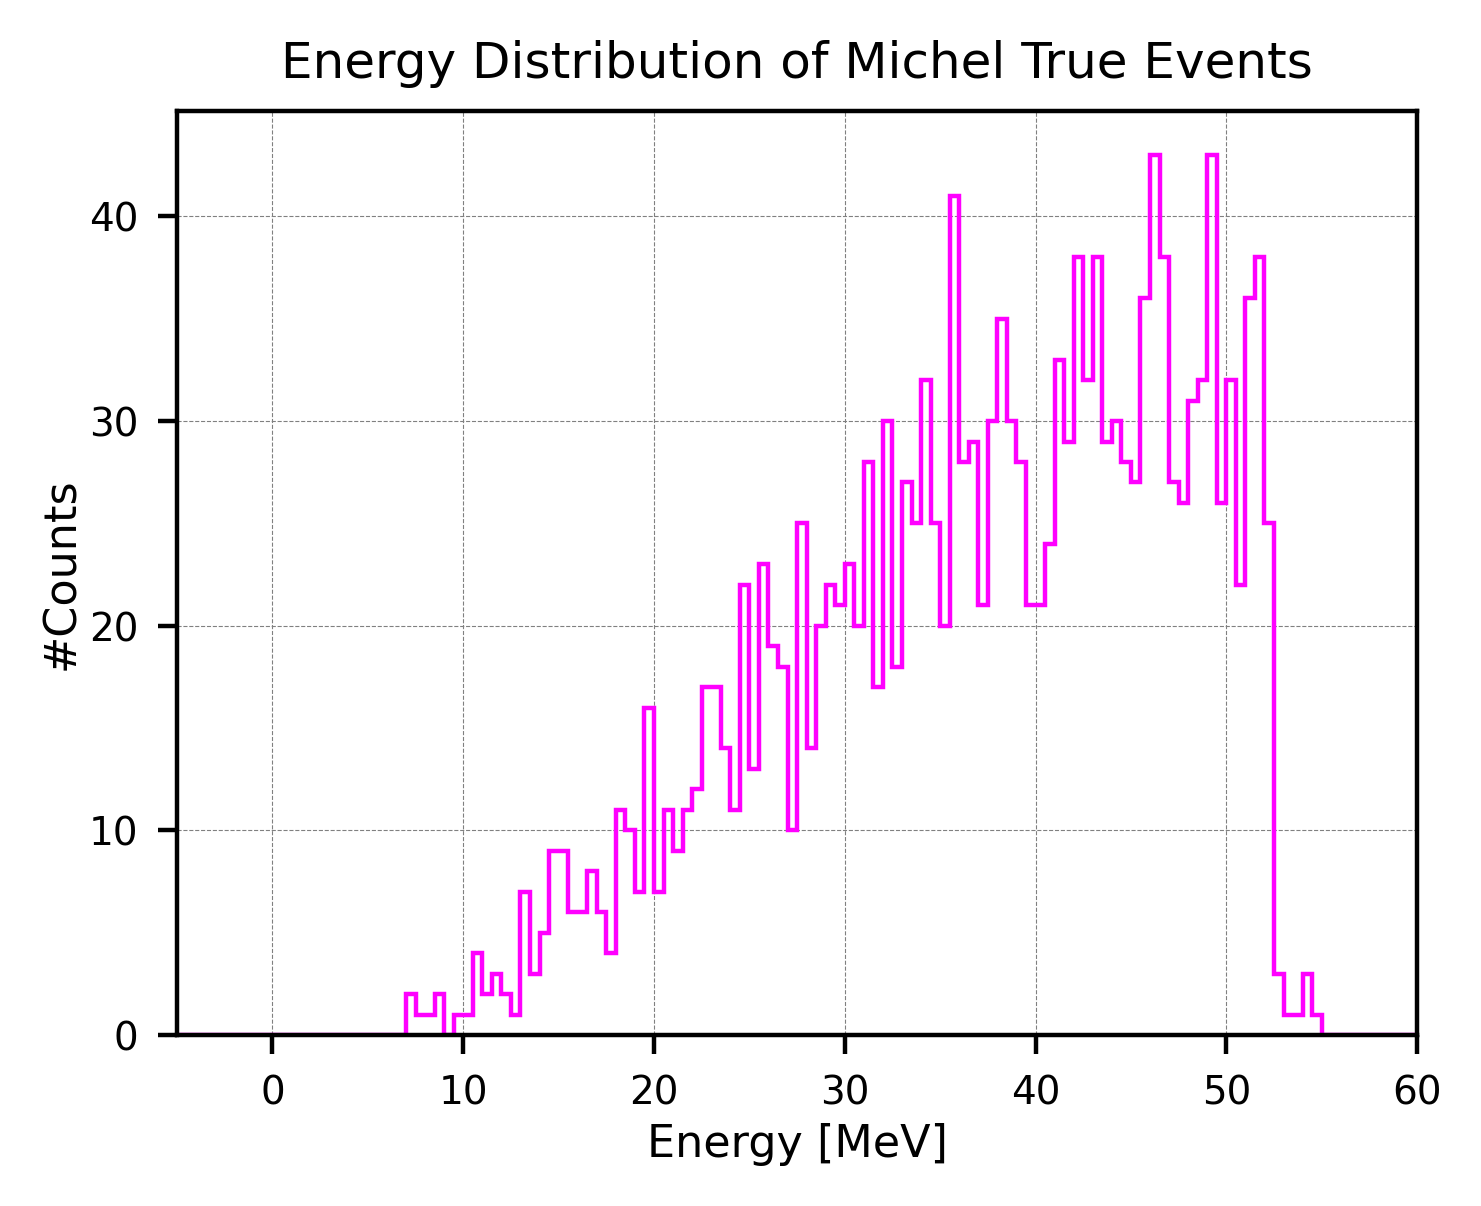

In [15]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]

lifetime = [ev.lifetime for ev in events_true_initial] #true lifetime---
energy = [ev.energy for ev in events_true_initial] 


#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()







#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(lifetime, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(energy, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  





<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals (constrain muTime to [120, 130])

Muon events selection (mu peak constrained to [120, 130]):
Updated Muon events:  1867 (95.60%)
Length of time_difference (Updated):  1867

Michel purity:  1686 /  1867 (90.31%)


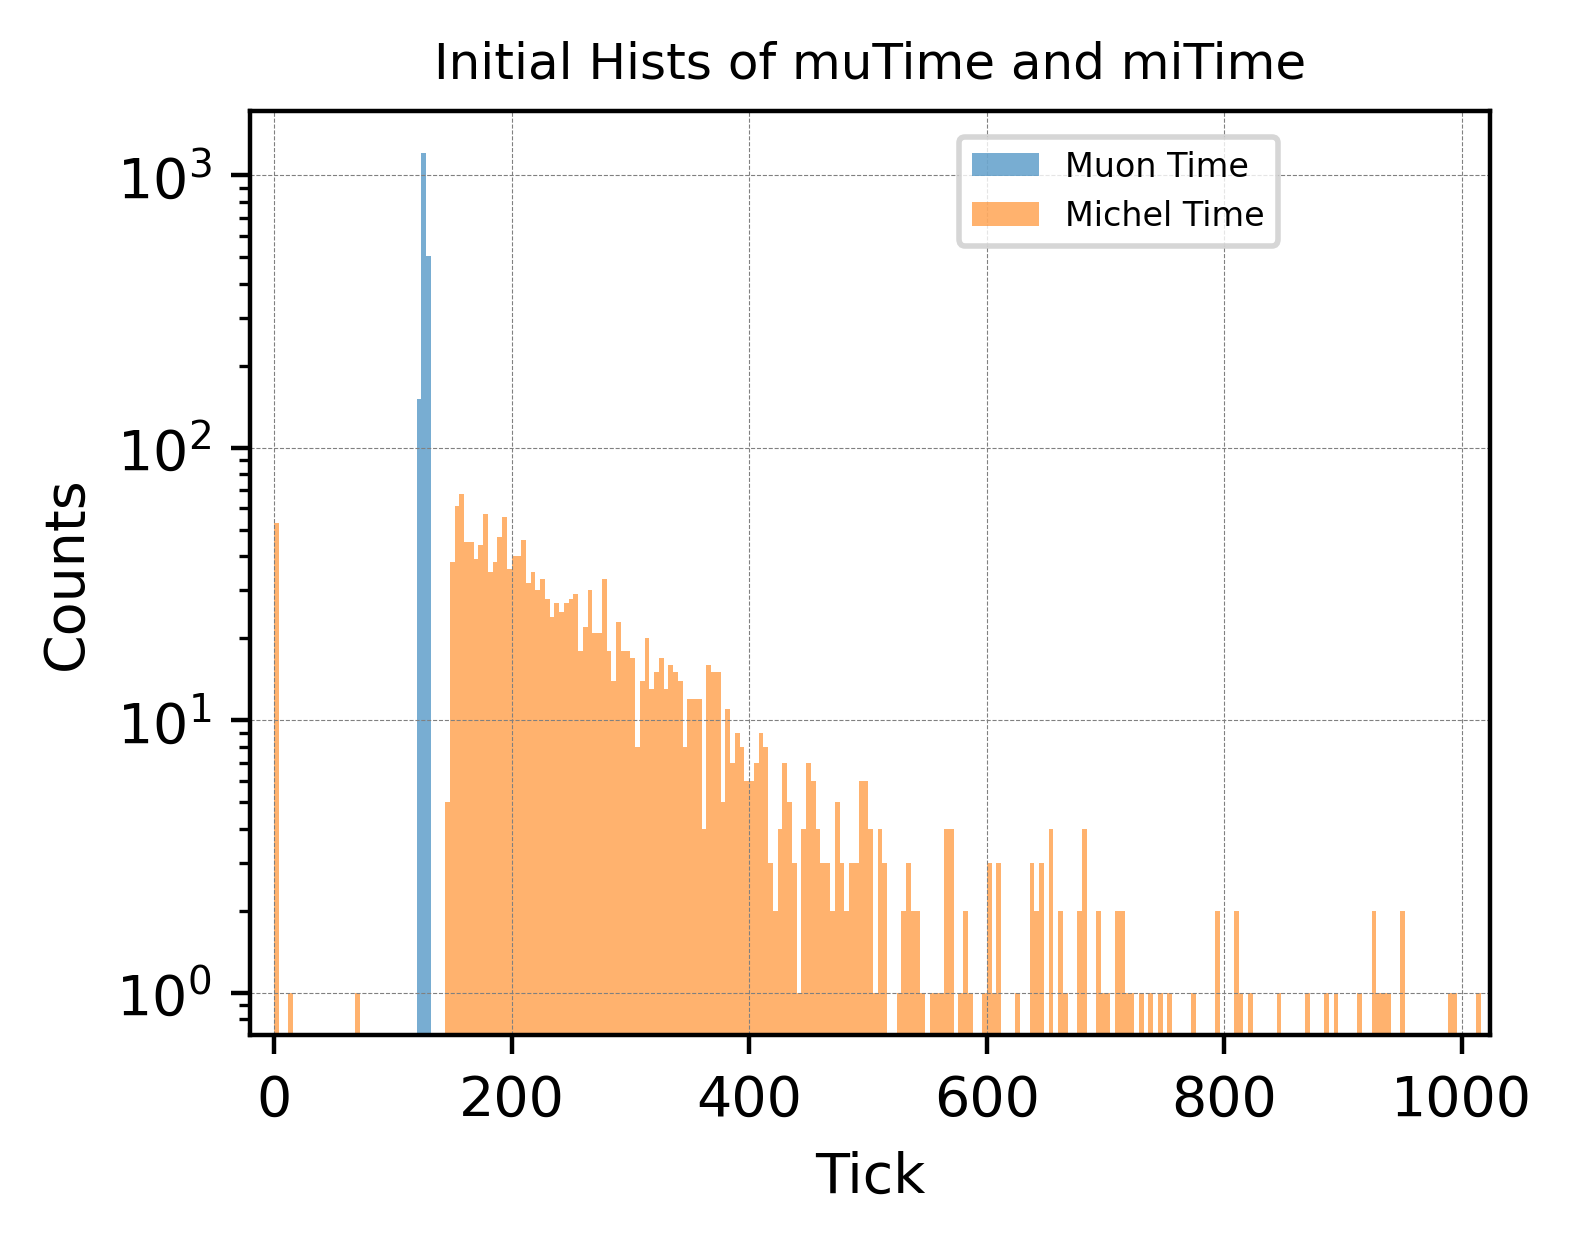




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  1867


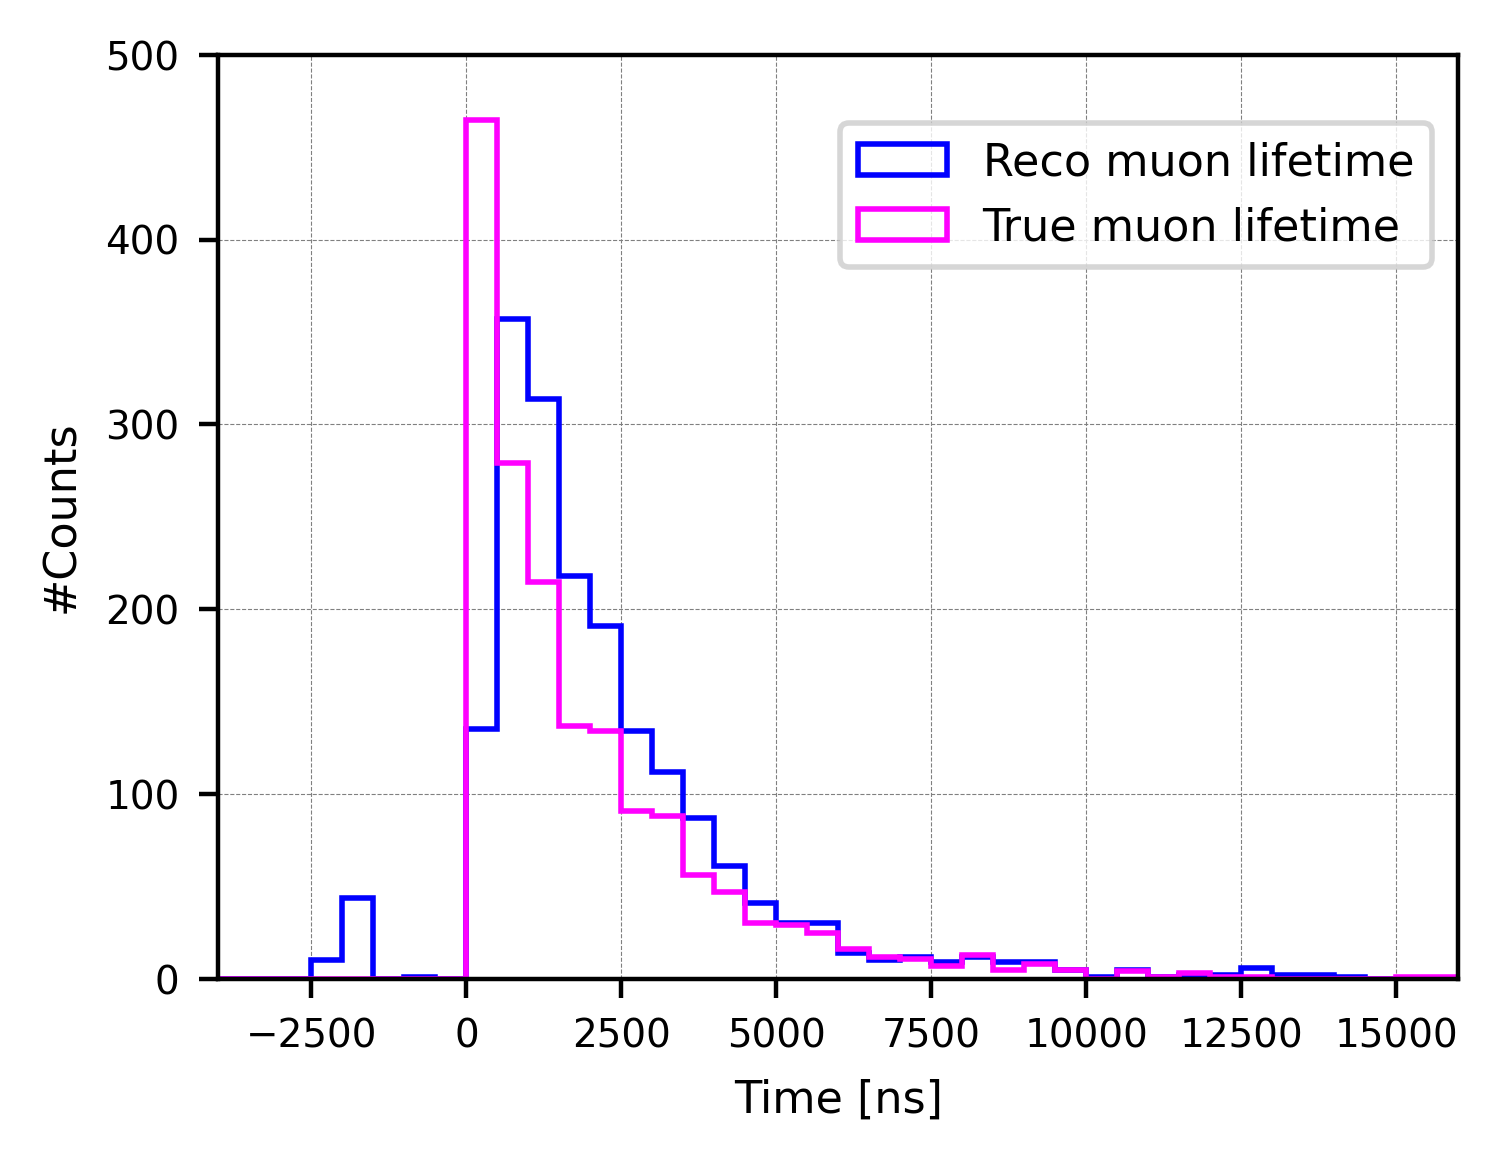

In [17]:
events_reco_update1 = []
events_true_update1 = []

lifetime_reco_update1 = []

for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time
    energy = ev.energy

    if 120 <= muTime <= 130:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if energy > 0:
            events_true_update1.append(ev)


print("Muon events selection (mu peak constrained to [120, 130]):")
print("Updated Muon events: ", len(events_reco_update1),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))

print("\nMichel purity: ", len(events_true_update1), "/ ", len(events_reco_update1), 
      "({:.2f}%)".format(len(events_true_update1)/len(events_reco_update1)*100)) 









#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---

lifetime_true_update1 = [ev.lifetime for ev in events_true_update1]
lifetime_update_ns = [value * 1000 for value in lifetime_true_update1]#True lifetime---


print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.hist(lifetime_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.ylim(0, 500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification 2: remove events with unphysical lifetime (constrain lifetime to [500, inf))




Lifetime distribution (Updated):
# Updated Candidates [500, 16000]:  1677

#Purity:  1516 / 1677 (90.40%)


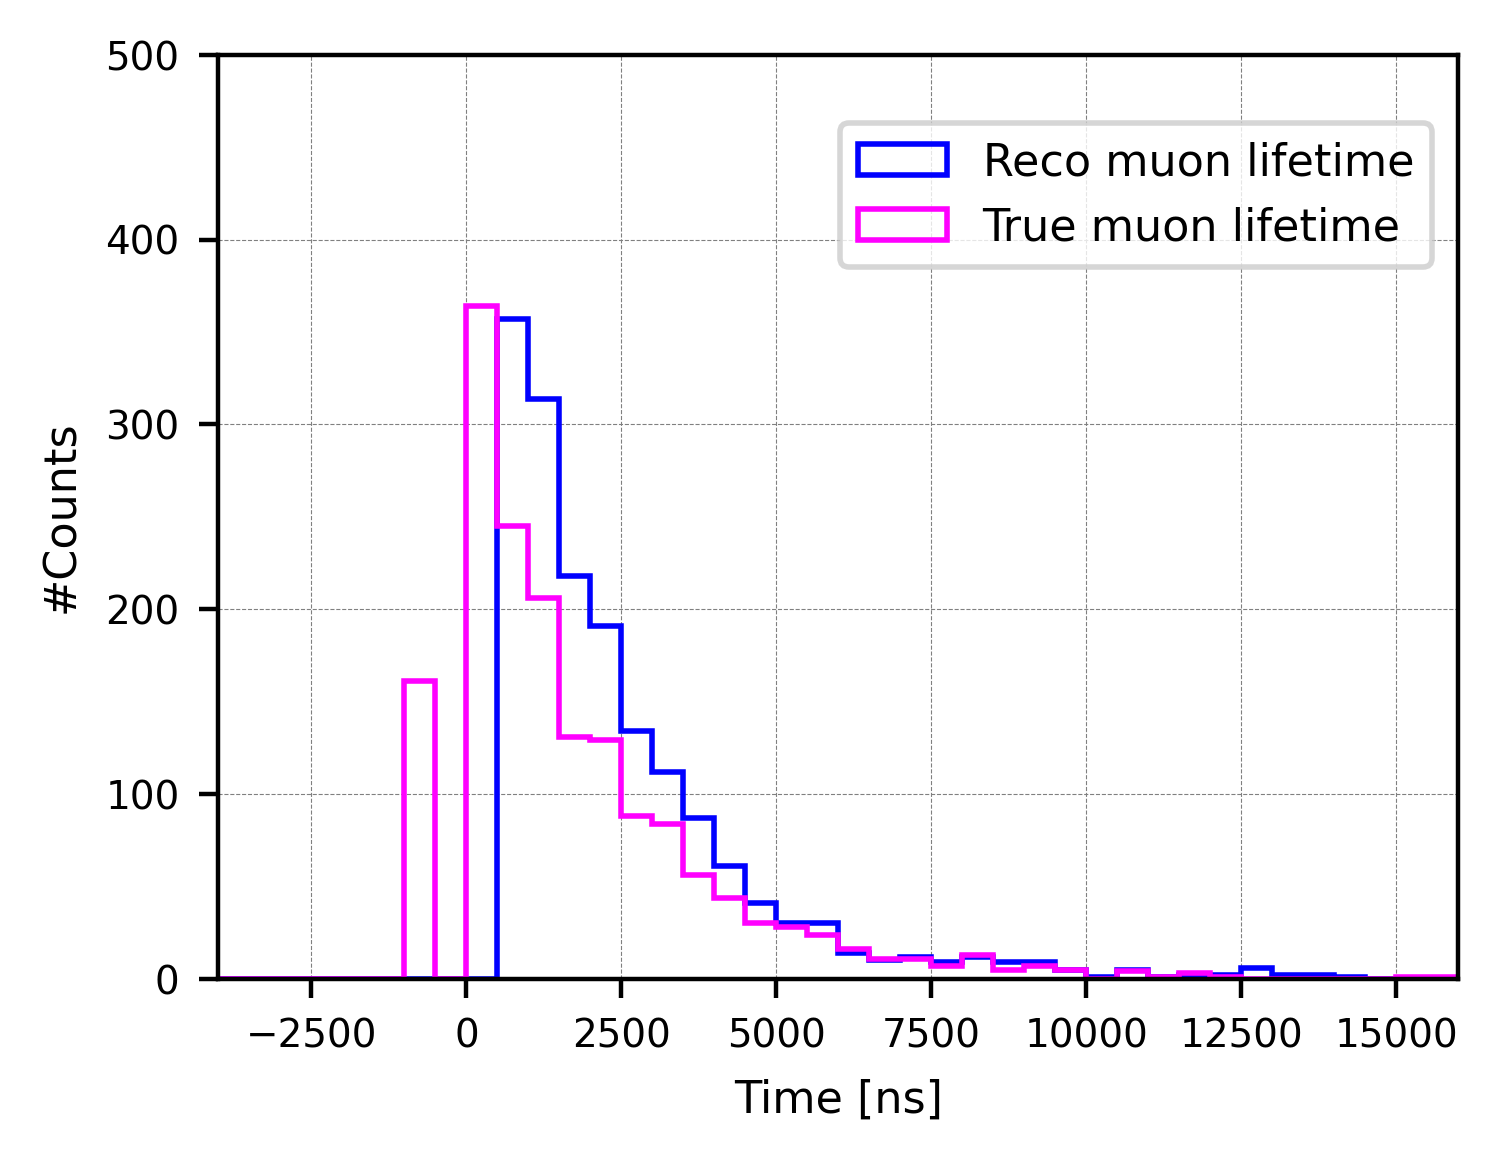


--------------------------------------
[-500, 500]:  931 / 1677 (55.52%)


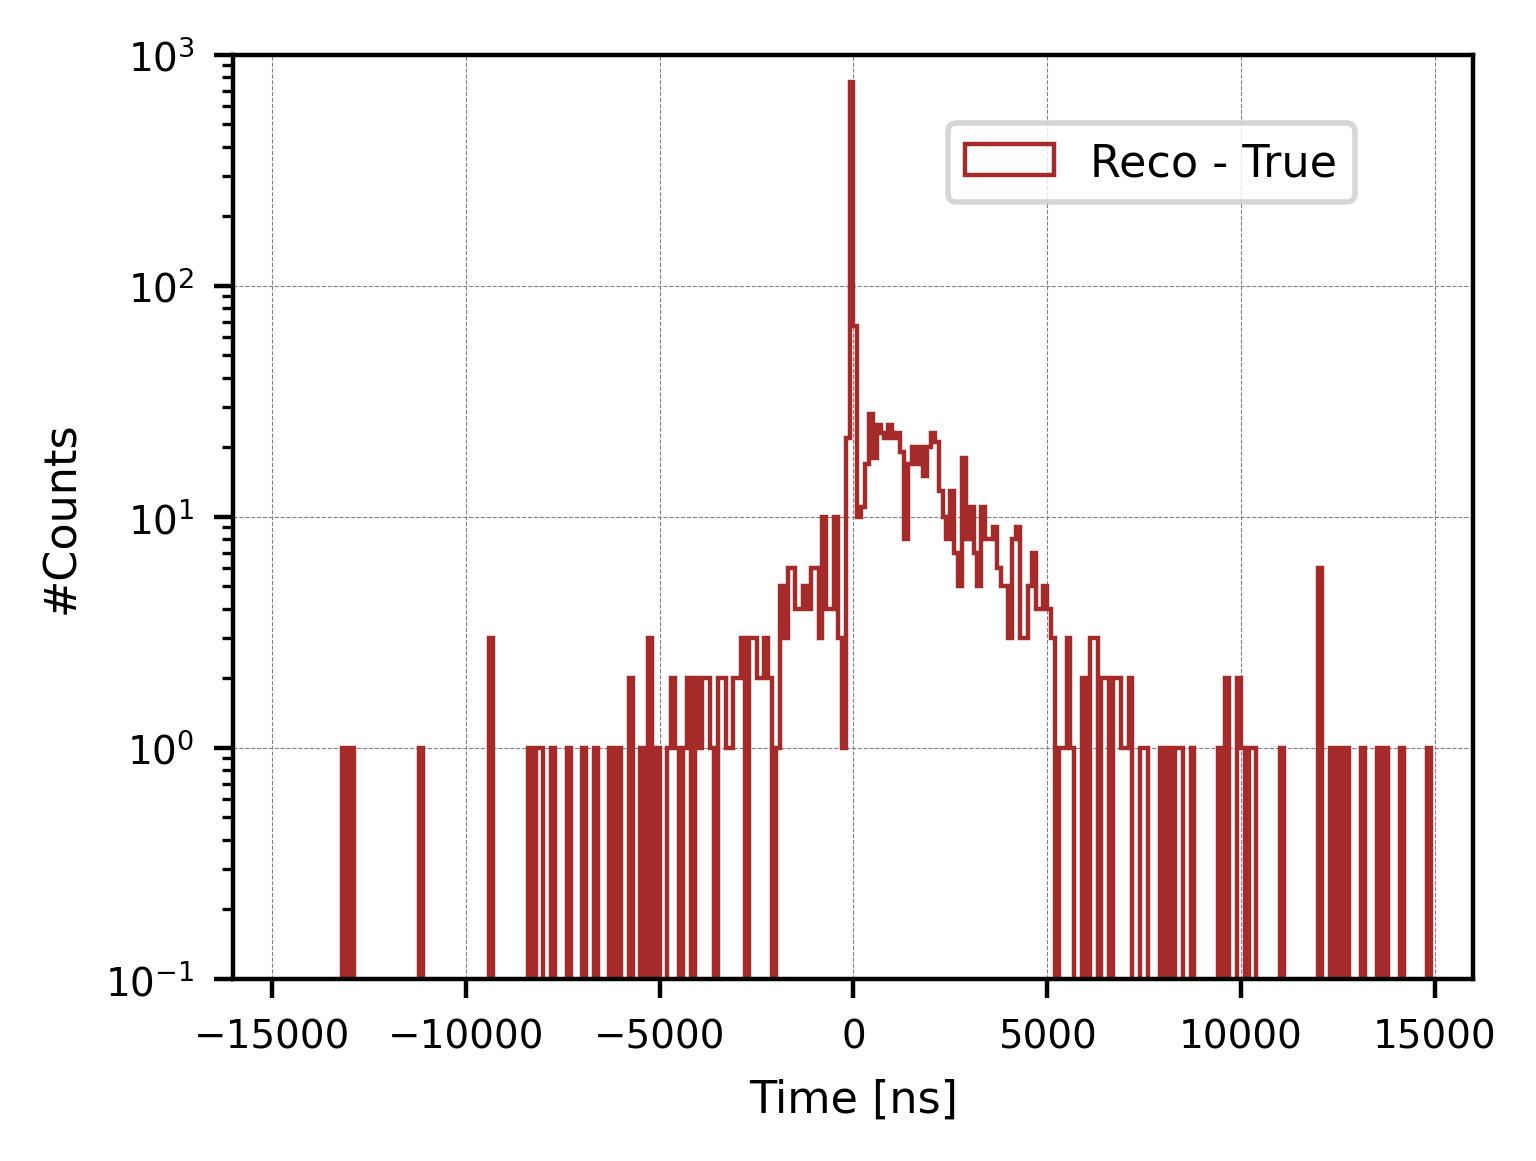

In [19]:
events_reco_update2 = []#Dataset after Purification 2---
events_true_update2 = []
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    e = ev.energy

    if 500 <= timeDiff:
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)

        if e > 0:
            events_true_update2.append(ev)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [500, 16000]: ", len(events_reco_update2))

        
print("\n#Purity: ", len(events_true_update2), "/", len(events_reco_update2), 
     "({:.2f}%)".format(len(events_true_update2)/len(events_reco_update2)*100))







# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')


lifetime_update_ns2 = [ev.lifetime * 1000 for ev in events_reco_update2]#True lifetime (contain false)---
plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.ylim(0, 500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#---------------------------------------------------------------
#Reco True difference-------------------------------------------

diff_reco_true = []
for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    lifetime = ev.lifetime * 1000 #convert to ns---

    diff_reco_true.append(timeDiff-lifetime)


reco_true_count_500 = sum(-500 <= x <= 500 for x in diff_reco_true)
print("\n--------------------------------------")
print("[-500, 500]: ", reco_true_count_500, "/", len(diff_reco_true), 
     "({:.2f}%)".format(reco_true_count_500/len(diff_reco_true)*100))


#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')


plt.xlim(-16000, 16000)
plt.ylim(0.1, 1000)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






### Event-by-event Inspection:

Reco with 500ns < True.   :  1152 / 1677 (68.69%)
Reco with 0 < True < 500ns:  364 / 1677 (21.71%)
Reco with True < 0 (False):  161 / 1677 (9.60%)


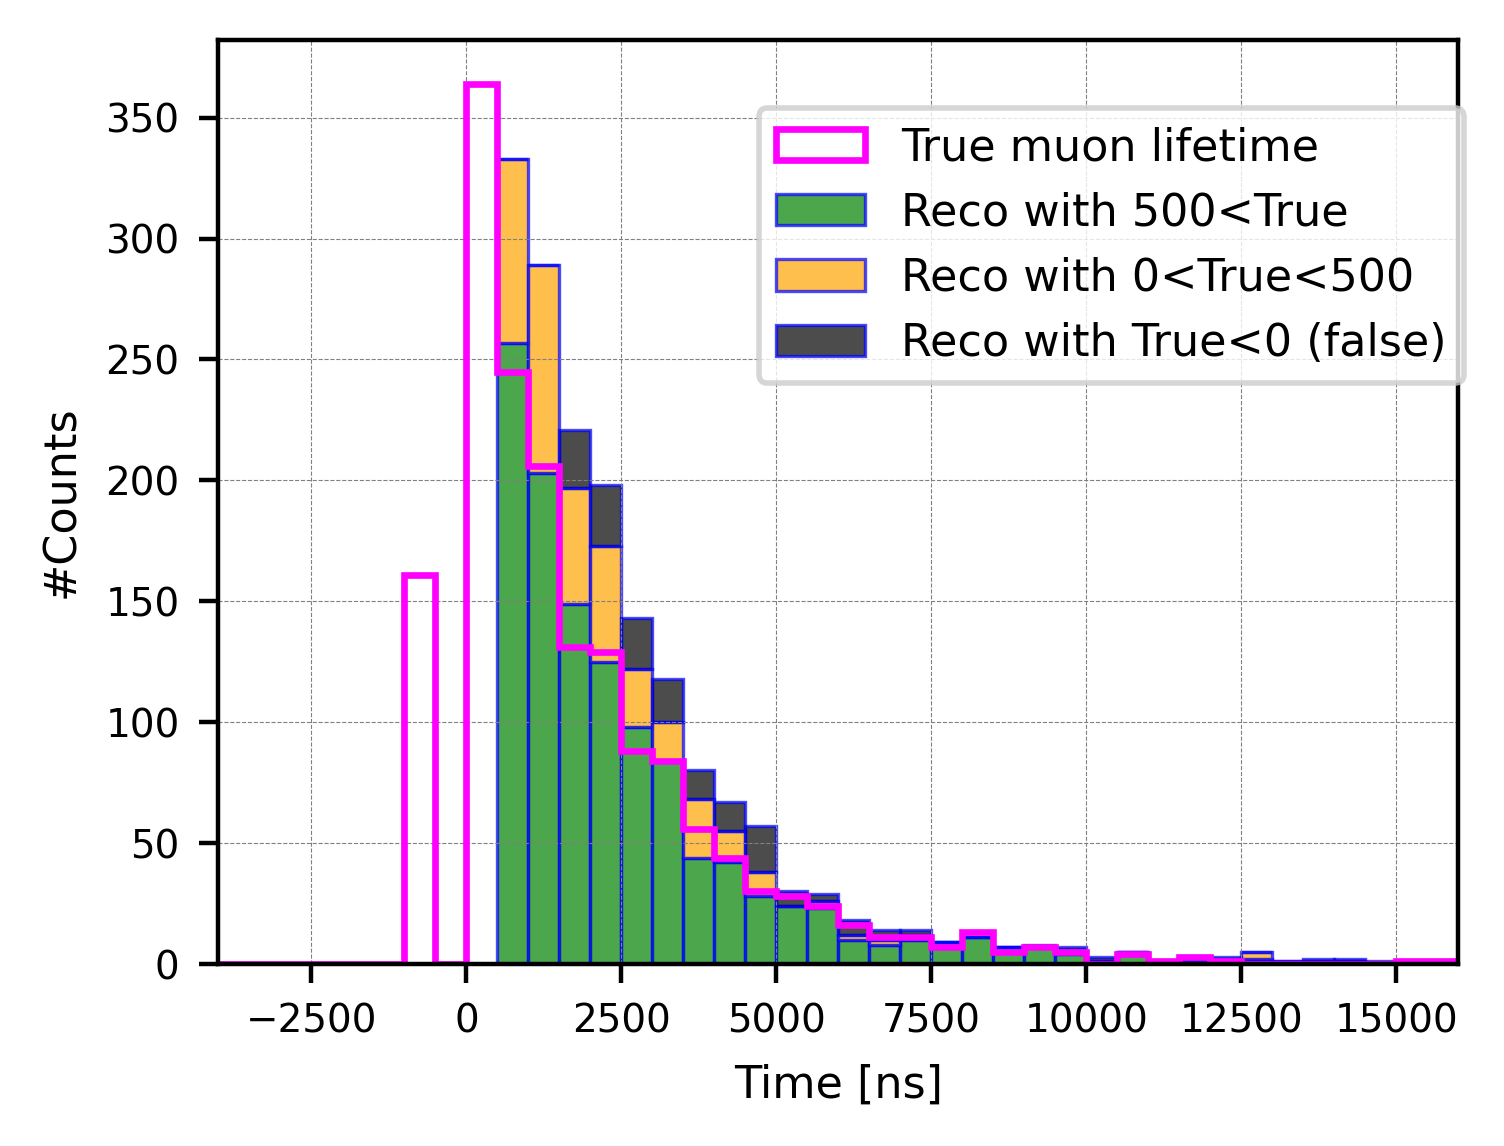

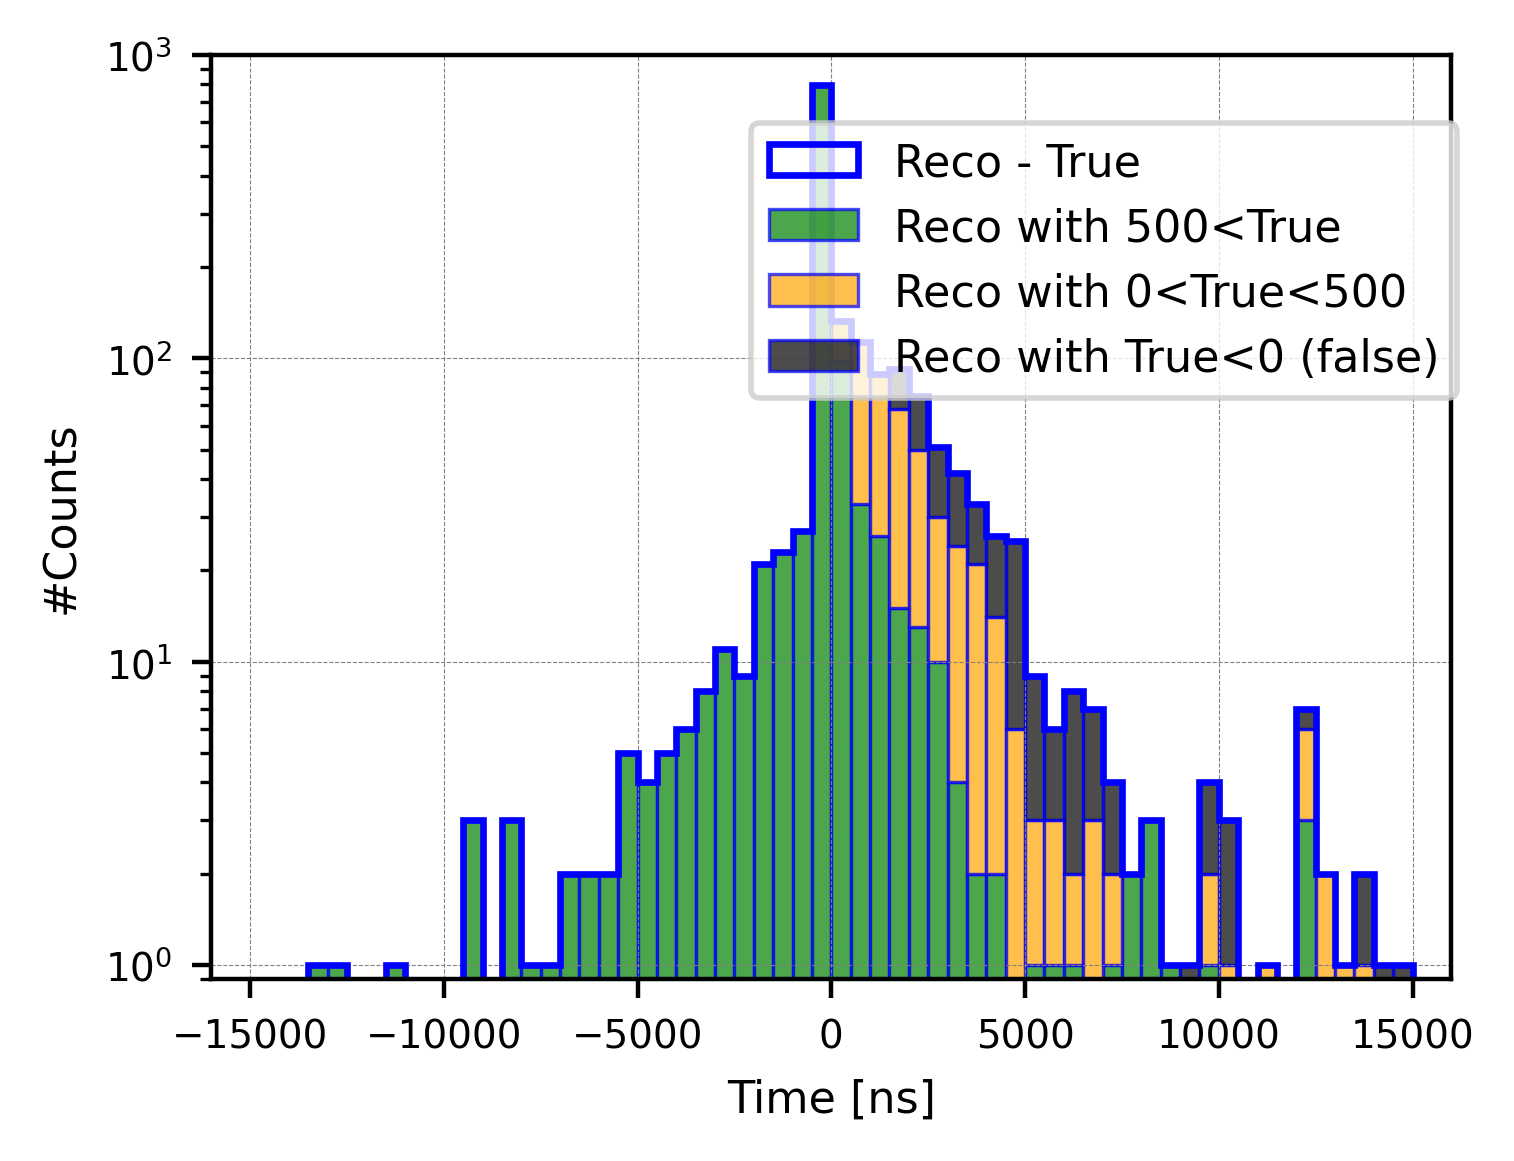

In [45]:
#lifetime_reco_update2 and lifetime_update_ns2 are the final dataset!!!

reco_true500 = [] #reco with 500 < true
reco_true0 = [] #reco with 0 < true < 500
reco_false = [] #reco with true < 0

diff_total = [] #reco - true
diff_true500 = [] #(reco-true) with 500 < true
diff_true0 = [] # 0 < true < 500
diff_false = [] # true < 0

for i in range(0, len(lifetime_update_ns2)):
    reco = lifetime_reco_update2[i]
    true = lifetime_update_ns2[i]

    diff_total.append(reco-true)

    if 500 < true:
        reco_true500.append(reco)
        diff_true500.append(reco-true)
    elif 0 < true < 500:
        reco_true0.append(reco)
        diff_true0.append(reco-true)
    elif true < 0:
        reco_false.append(reco)
        diff_false.append(reco-true)


print("Reco with 500ns < True.   : ", len(reco_true500), "/", len(lifetime_reco_update2), 
     "({:.2f}%)".format(len(reco_true500)/len(lifetime_reco_update2)*100))
print("Reco with 0 < True < 500ns: ", len(reco_true0), "/", len(lifetime_reco_update2), 
     "({:.2f}%)".format(len(reco_true0)/len(lifetime_reco_update2)*100))
print("Reco with True < 0 (False): ", len(reco_false), "/", len(lifetime_reco_update2), 
     "({:.2f}%)".format(len(reco_false)/len(lifetime_reco_update2)*100))




# Muon Lifetime distribution====================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram----------------------
plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.2,
         label='True muon lifetime')


# Stacked reco Michel histogram
plt.hist([reco_true500, reco_true0, diff_false], bins=bins, range=(range_min, range_max),
         color=['green', 'orange', 'black'], alpha=0.7,
         edgecolor='blue', histtype='bar', linewidth=0.6,
         label=['Reco with 500<True', 'Reco with 0<True<500', 'Reco with True<0 (false)'],
         stacked=True)


plt.xlim(-4000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.72, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()








# Diff distribution====================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram----------------------
plt.hist(diff_total, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.2,
         label='Reco - True')


# Stacked reco Michel histogram
plt.hist([diff_true500, diff_true0, diff_false], bins=bins, range=(range_min, range_max),
         color=['green', 'orange', 'black'], alpha=0.7,
         edgecolor='blue', histtype='bar', linewidth=0.6,
         label=['Reco with 500<True', 'Reco with 0<True<500', 'Reco with True<0 (false)'],
         stacked=True)


plt.xlim(-16000, 16000)
plt.ylim(0.9, 1000)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.72, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()




### Lifetime fittings:

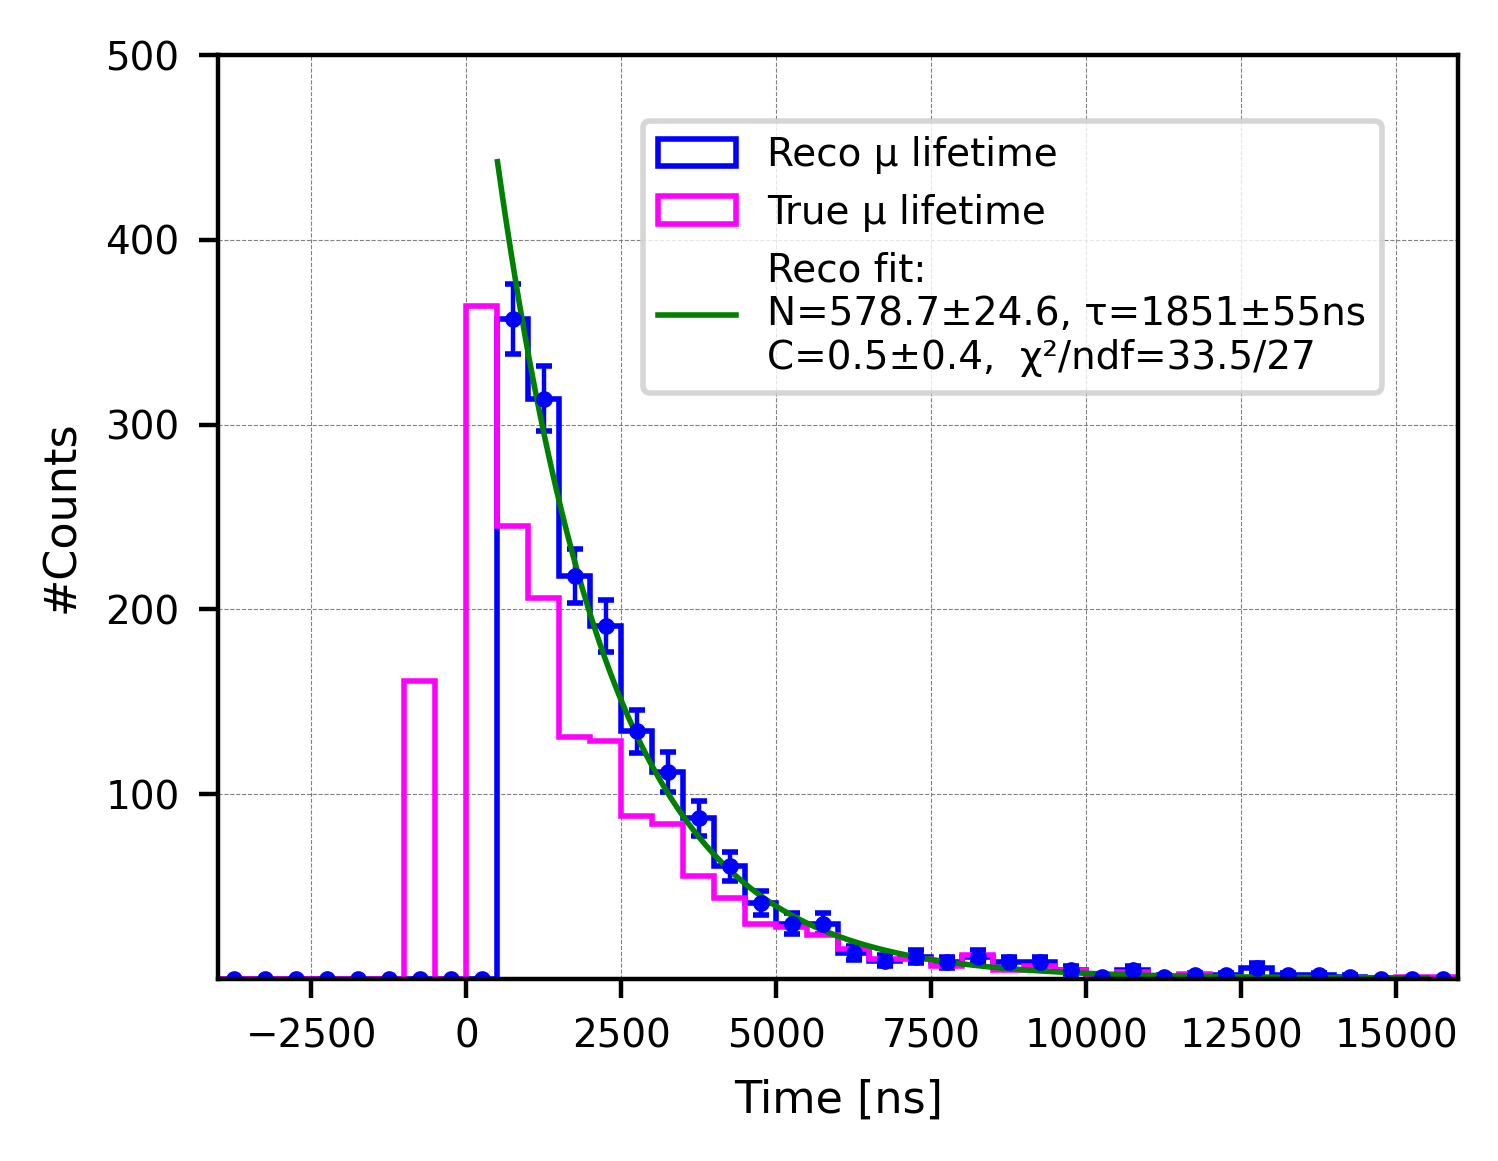

In [38]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt



#======Single Fitting==================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histograms (Reco + True, but error bars only for Reco)
counts_reco, bin_edges_reco, _ = plt.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=1.0,
    label='Reco μ lifetime'
)

# Add error bars for Reco
bin_centers_reco = 0.5 * (bin_edges_reco[:-1] + bin_edges_reco[1:])
errors_reco = np.sqrt(np.clip(counts_reco, 0, None))
plt.errorbar(
    bin_centers_reco, counts_reco, yerr=errors_reco,
    fmt='o', color='blue', markersize=2.0, elinewidth=0.8, capsize=1.5,
    label=None  # don’t duplicate legend entry
)

# True μ histogram
plt.hist(
    lifetime_update_ns2, bins=bins, range=(range_min, range_max),
    edgecolor='magenta', histtype='step', linewidth=1.0,
    label='True μ lifetime'
)

# ---------- add χ² fits with constant background ----------
def exp1C(t, N, tau, C):
    return N * np.exp(-t / tau) + C

def fit_and_overlay(sample, label, fit_min, fit_max, color=None, line_style='-'):
    # Use the SAME binning
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fit window
    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label}")
        return

    # Uncertainty per bin
    sigma = np.sqrt(np.clip(y, 1.0, None))

    # Initial guesses
    N0 = float(y.max())
    tau0 = max(100.0, (np.sum(y * (x - fit_min)) / max(np.sum(y), 1.0)))  # ns
    C0 = min(y)  # background level ~ lowest bin

    # Weighted least squares (χ²)
    popt, pcov = curve_fit(exp1C, x, y, p0=[N0, tau0, C0],
                           sigma=sigma, absolute_sigma=True, maxfev=20000)
    N_fit, tau_fit, C_fit = popt
    N_err, tau_err, C_err = np.sqrt(np.diag(pcov))

    # χ²/ndf
    yfit = exp1C(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf = max(len(x) - len(popt), 1)

    # Overlay smooth curve
    t_smooth = np.linspace(fit_min, fit_max, 400)
    plt.plot(
        t_smooth,
        exp1C(t_smooth, *popt),
        line_style,
        linewidth=1.0,
        color=color,
        label=(
            f"{label} fit:\n"
            f"N={N_fit:.1f}±{N_err:.1f}, τ={tau_fit:.0f}±{tau_err:.0f}ns\n"
            f"C={C_fit:.1f}±{C_err:.1f},  χ²/ndf={chi2:.1f}/{ndf}"
        ),
    )


# Fit windows
fit_and_overlay(lifetime_reco_update2, "Reco",  500, 15500, color="green", line_style='-')
#fit_and_overlay(lifetime_update_ns2, "True",     0, 15500, color="magenta")
# ---------- end fits ----------

plt.xlim(-4000, 16000)
plt.ylim(0.1, 500)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=9,
           markerscale=5, ncol=1, prop={'size':7})
plt.show()


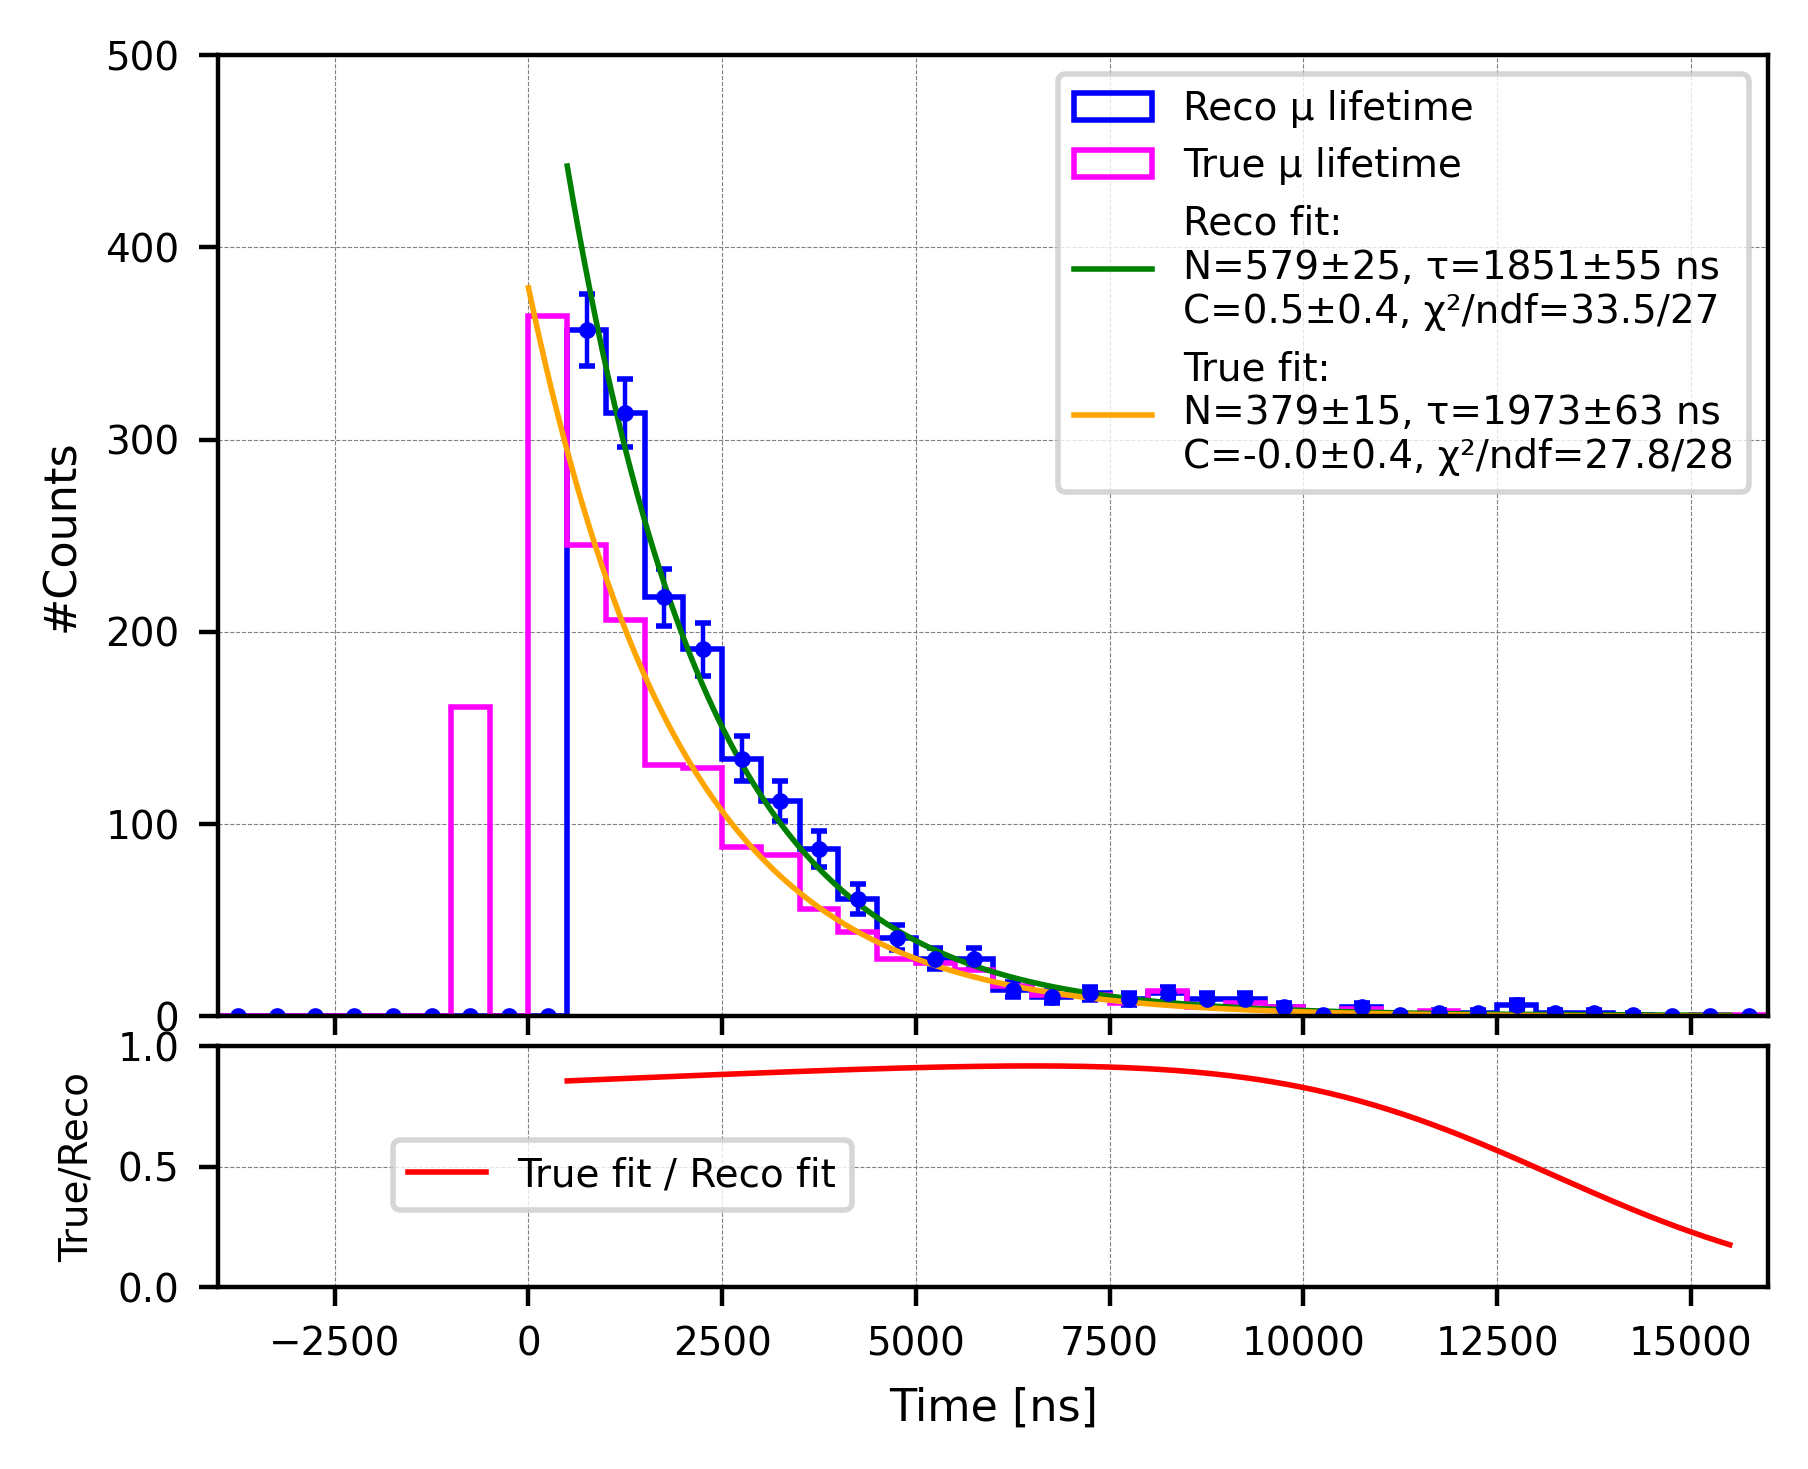

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

#======Double Fitting with Ratio Panel==================================================
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Histogram binning
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Exponential + constant model
def exp1C(t, N, tau, C):
    return N * np.exp(-t / tau) + C

def fit_and_overlay(ax, sample, label, fit_min, fit_max, color=None, line_style='-'):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label}")
        return None, None

    sigma = np.sqrt(np.clip(y, 1.0, None))
    N0 = float(y.max())
    tau0 = max(100.0, (np.sum(y * (x - fit_min)) / max(np.sum(y), 1.0)))
    C0 = min(y)

    popt, pcov = curve_fit(exp1C, x, y, p0=[N0, tau0, C0],
                           sigma=sigma, absolute_sigma=True, maxfev=20000)
    N_fit, tau_fit, C_fit = popt
    N_err, tau_err, C_err = np.sqrt(np.diag(pcov))

    yfit = exp1C(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf = max(len(x) - len(popt), 1)

    # Overlay fit
    t_smooth = np.linspace(fit_min, fit_max, 400)
    ax.plot(
        t_smooth, exp1C(t_smooth, *popt),
        line_style, linewidth=1.0, color=color,
        label=(
            f"{label} fit:\n"
            f"N={N_fit:.0f}±{N_err:.0f}, τ={tau_fit:.0f}±{tau_err:.0f} ns\n"
            f"C={C_fit:.1f}±{C_err:.1f}, χ²/ndf={chi2:.1f}/{ndf}"
        )
    )
    return t_smooth, exp1C(t_smooth, *popt)

# -------- Top panel (histograms + fits) --------
ax1 = fig.add_subplot(gs[0])

# Reco histogram + error bars
counts_reco, bin_edges_reco, _ = ax1.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=1.0, label='Reco μ lifetime'
)
bin_centers_reco = 0.5 * (bin_edges_reco[:-1] + bin_edges_reco[1:])
errors_reco = np.sqrt(np.clip(counts_reco, 0, None))
ax1.errorbar(bin_centers_reco, counts_reco, yerr=errors_reco,
             fmt='o', color='blue', markersize=2.0, elinewidth=0.8, capsize=1.5)

# True histogram
ax1.hist(
    lifetime_update_ns2, bins=bins, range=(range_min, range_max),
    edgecolor='magenta', histtype='step', linewidth=1.0, label='True μ lifetime'
)

# Fits
t_reco, fit_reco = fit_and_overlay(ax1, lifetime_reco_update2, "Reco",  500, 15500, color="green")
t_true, fit_true = fit_and_overlay(ax1, lifetime_update_ns2, "True",   0, 15500, color="orange")

# Top panel styling
ax1.set_xlim(-4000, 16000)
ax1.set_ylim(0, 500)
ax1.set_ylabel('#Counts', fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax1.legend(loc='upper right', fontsize=8, markerscale=6, ncol=1, prop={'size':7})

# -------- Bottom panel (ratio True/Reco) --------
ax2 = fig.add_subplot(gs[1], sharex=ax1)

if t_reco is not None and t_true is not None:
    ratio = np.divide(fit_true, fit_reco, out=np.zeros_like(fit_true), where=(fit_reco > 0))
    ax2.plot(t_reco, ratio, color='red', linewidth=1.0, label='True fit / Reco fit')

ax2.set_xlim(-4000, 16000)
ax2.set_ylim(0.0, 1.0)
ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel('True/Reco', fontsize=7)
ax2.tick_params(labelsize=7)
ax2.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax2.legend(loc='upper left', bbox_to_anchor=(0.1, 0.69), fontsize=7)

plt.show()


<br />
<br />
<br />
<br />

## Explore Final Dataset (After purification 2):

In [54]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None #in unit of us---
    pdg: Optional[int] = None
    reco_lifetime: Optional[float] = None
    true_lifetime: Optional[float] = None # in unit of ns---
    diff_lifetime: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))

#New calculated reco & true lifetime lists:
recoLife_update2 = []
trueLife_update2 = []  
diffLife_update2 = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)
    trueLife_update2.append(ev.lifetime * 1000)
    diffLife_update2.append(timeDiff - ev.lifetime * 1000)
 

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))
print("Size of lifetime_update_ns2                 : ", len(trueLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, true_life, diff_life in zip(
    events_reco_update2, 
    recoLife_update2, 
    trueLife_update2, 
    diffLife_update2
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        energy=ev.energy,
        lifetime=ev.lifetime,
        pdg=ev.pdg,
        reco_lifetime=reco_life,
        true_lifetime=true_life,
        diff_lifetime=diff_life
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))


true_newClass = []
for ev in events_newClass:
    if ev.energy > 0:
        true_newClass.append(ev)

print("\nLength of final true in format of new class: ", len(true_newClass))

Size of events_reco_update2 (previous class):  1677
Size of lifetime_reco_update2               :  1677
Size of lifetime_update_ns2                 :  1677

Length of final dataset in format of new class:  1677

Length of final true in format of new class:  1516


### Space Distribution:


Decay points distribution: 

# of X < 0 :  392 (23.375%)
# of X >= 0:  1285 (76.625%)


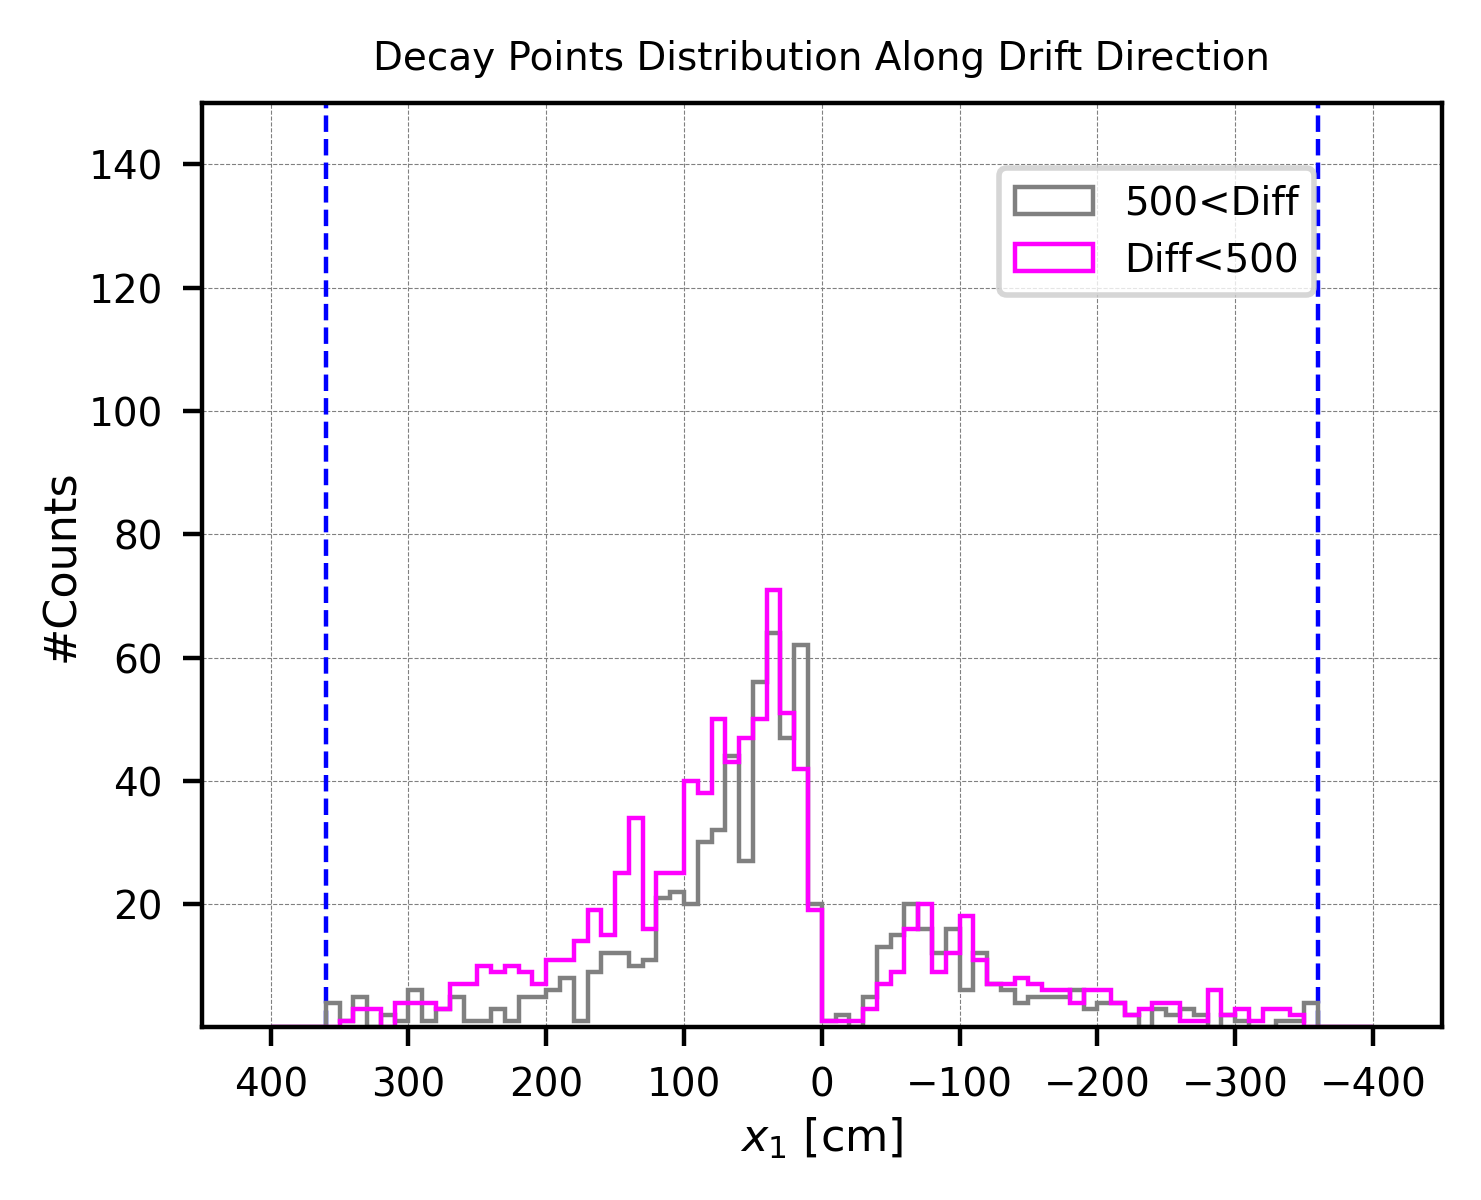

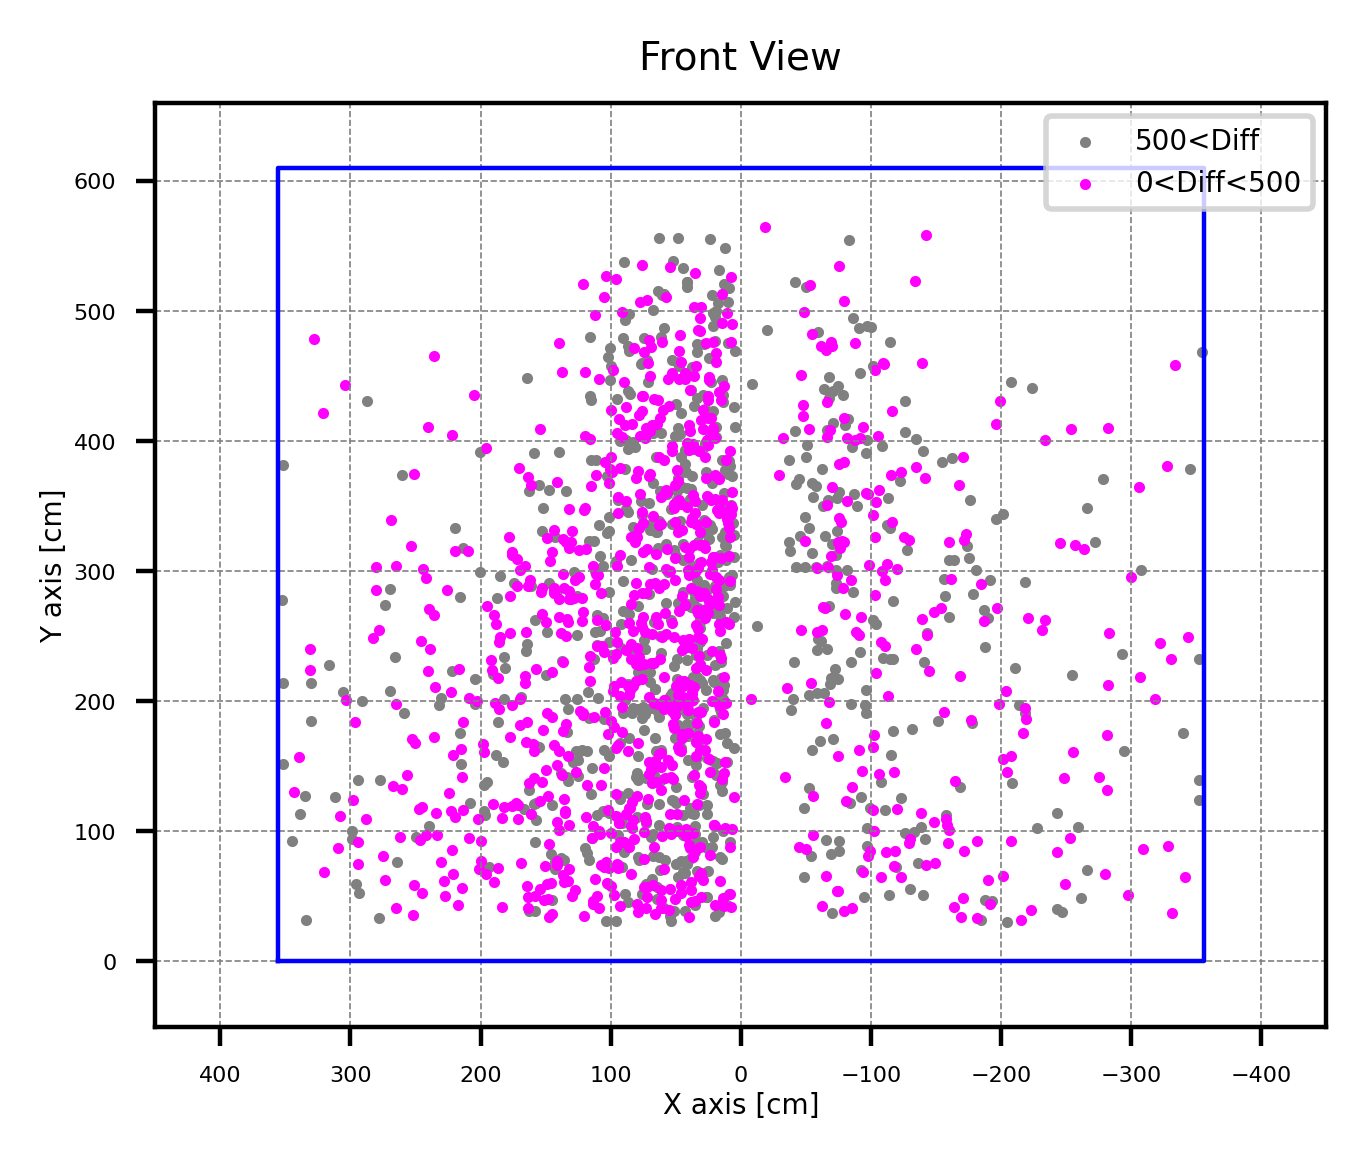

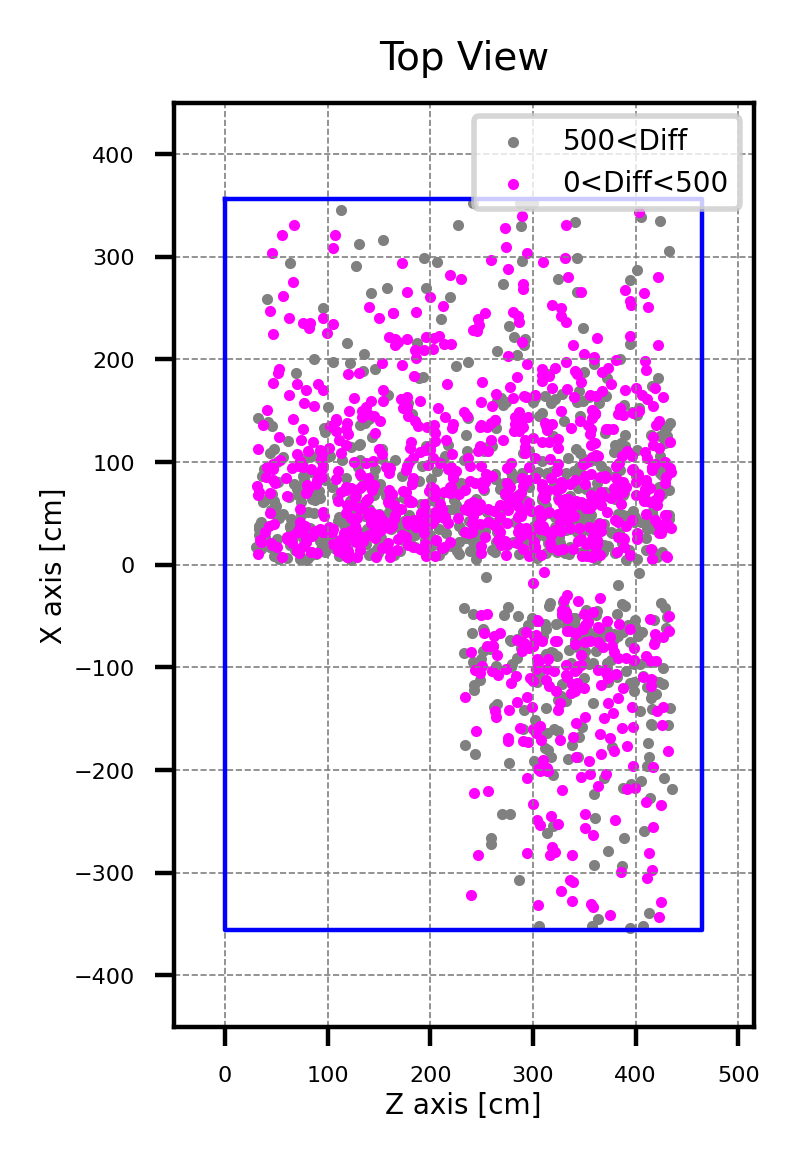

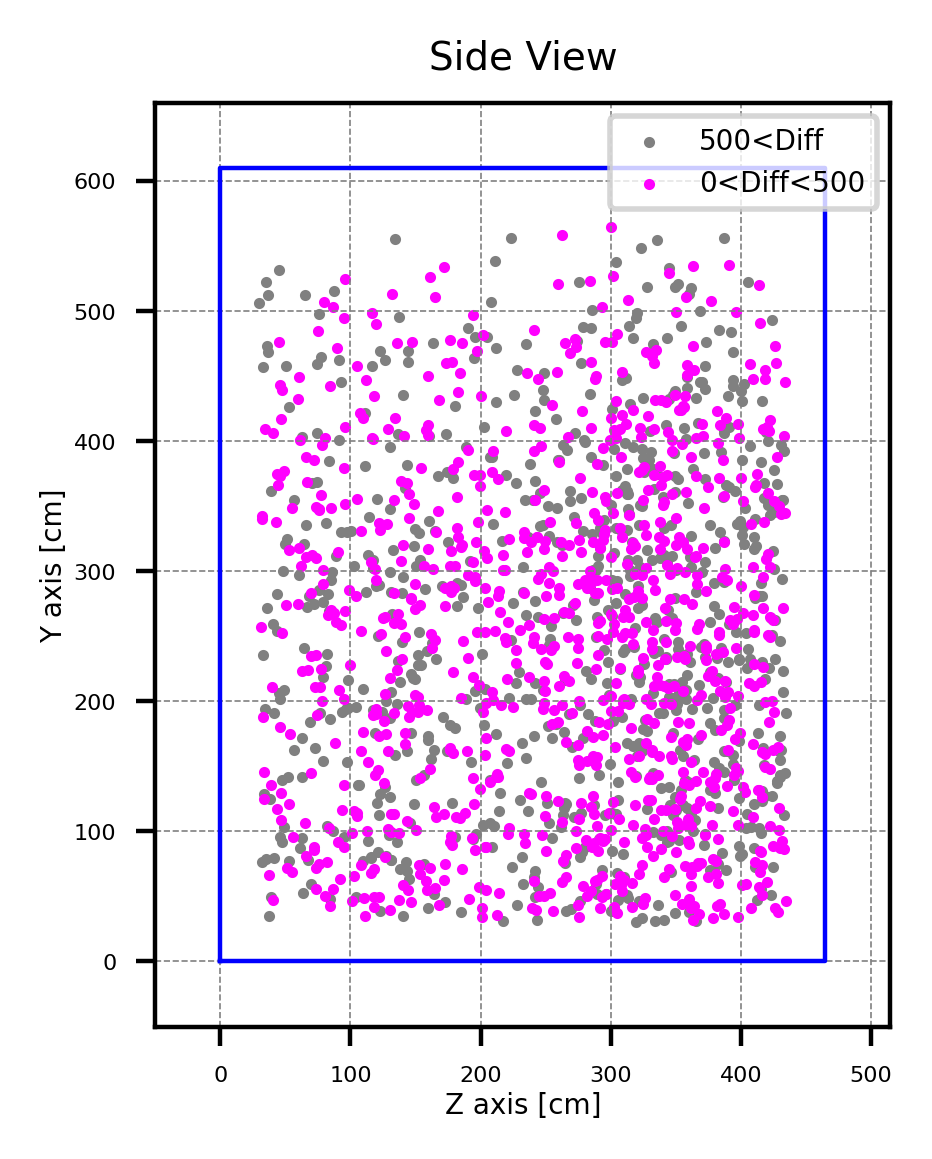

In [ ]:
muon_time = [ev.posX for ev in events_reco_initial]

#"Reco" final events---
final_posX = [ev.posX for ev in events_newClass]
final_posY = [ev.posY for ev in events_newClass]
final_posZ = [ev.posZ for ev in events_newClass]

#"True" final events---
true_posX = [ev.posX for ev in true_newClass]


events_true500 = []
events_true0 = []
events_false = []
events_diff500 = []
events_diff0 = [] #events with diff>500
for ev in events_newClass:
    trueL = ev.true_lifetime
    diff = ev.diff_lifetime

    if 500 < trueL:
        events_true500.append(ev)
    elif 0 < trueL <= 500:
        events_true0.append(ev)
    elif trueL <= 0:
        events_false.append(ev)

    if 500 < abs(diff):
        events_diff500.append(ev)
    else: #abs(diff) <= 500:
        events_diff0.append(ev)

posX_true500 = [ev.posX for ev in events_true500]
posY_true500 = [ev.posY for ev in events_true500]
posZ_true500 = [ev.posZ for ev in events_true500]

posX_true0 = [ev.posX for ev in events_true0]
posY_true0 = [ev.posY for ev in events_true0]
posZ_true0 = [ev.posZ for ev in events_true0]

posX_false = [ev.posX for ev in events_false]
posY_false = [ev.posY for ev in events_false]
posZ_false = [ev.posZ for ev in events_false]

posX_diff500 = [ev.posX for ev in events_diff500]
posY_diff500 = [ev.posY for ev in events_diff500]
posZ_diff500 = [ev.posZ for ev in events_diff500]


posX_diff0 = [ev.posX for ev in events_diff0]
posY_diff0 = [ev.posY for ev in events_diff0]
posZ_diff0 = [ev.posZ for ev in events_diff0]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(final_posX)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)
print("\n# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(decayX_initial)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(decayX_initial)*100))


# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
# plt.hist(posX_true500, bins=bins, range=(range_min, range_max), edgecolor='red', 
#          histtype='step', linewidth=0.8, label="500<True")
# plt.hist(posX_true0, bins=bins, range=(range_min, range_max), edgecolor='blue', 
#          histtype='step', linewidth=0.8, label="0<True<500")
# plt.hist(posX_false, bins=bins, range=(range_min, range_max), edgecolor='black', 
#          histtype='step', linewidth=0.8, label="True<0 (False)")

plt.hist(posX_diff500, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="500<Diff")
plt.hist(posX_diff0, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label="Diff<500")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 150)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  







# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Auxiliary line for field cage
aux2 = [0, 610, 610, 0, 0]
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Scatter plot----------
# plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.xlim(xmin, xmax)
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Auxiliary line
aux1 = [0, 465, 465, 0, 0]
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Scatter plot----------
# plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.ylim(xmin, xmax)
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()


# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Auxiliary line
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Scatter plot----------
# plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.xlim(-50, 515)
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()


### Lifetime & Energy of True Michels:


Michel e^+:  1262 / 1516 (83.25%)
Michel e^-:  254 / 1516 (16.75%)
#e^+ / #e^-:  1262 / 254 (4.97)


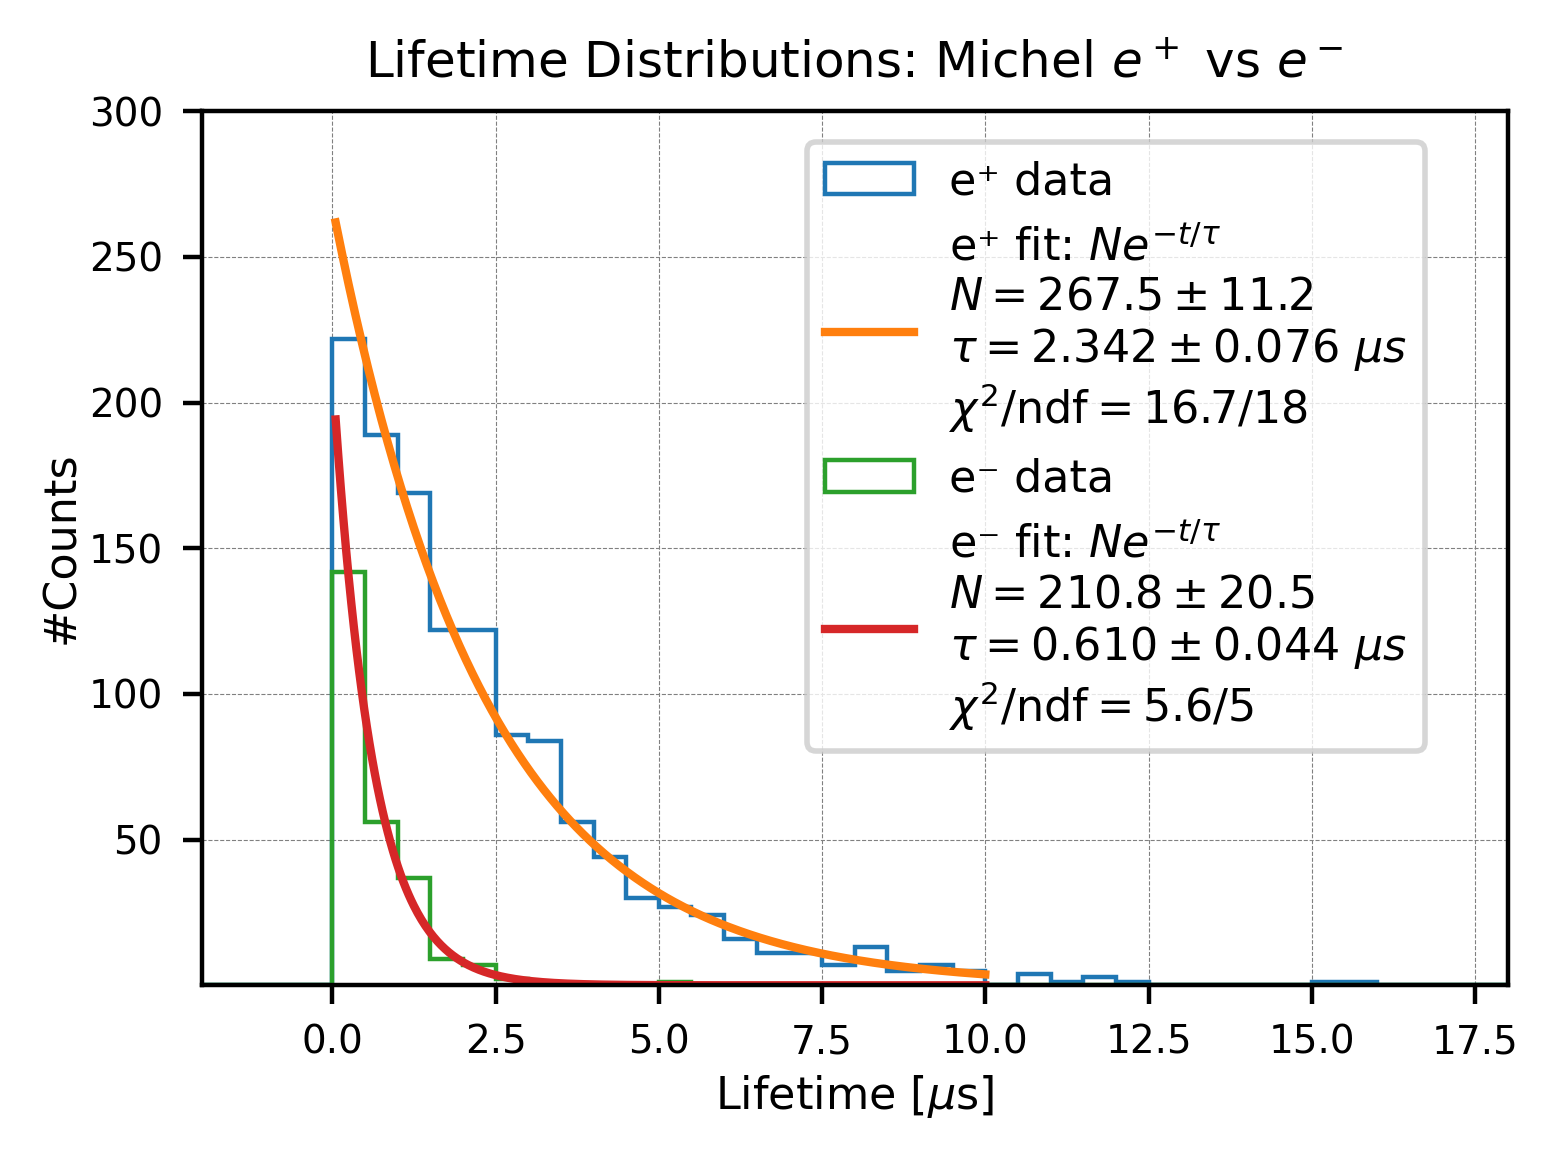

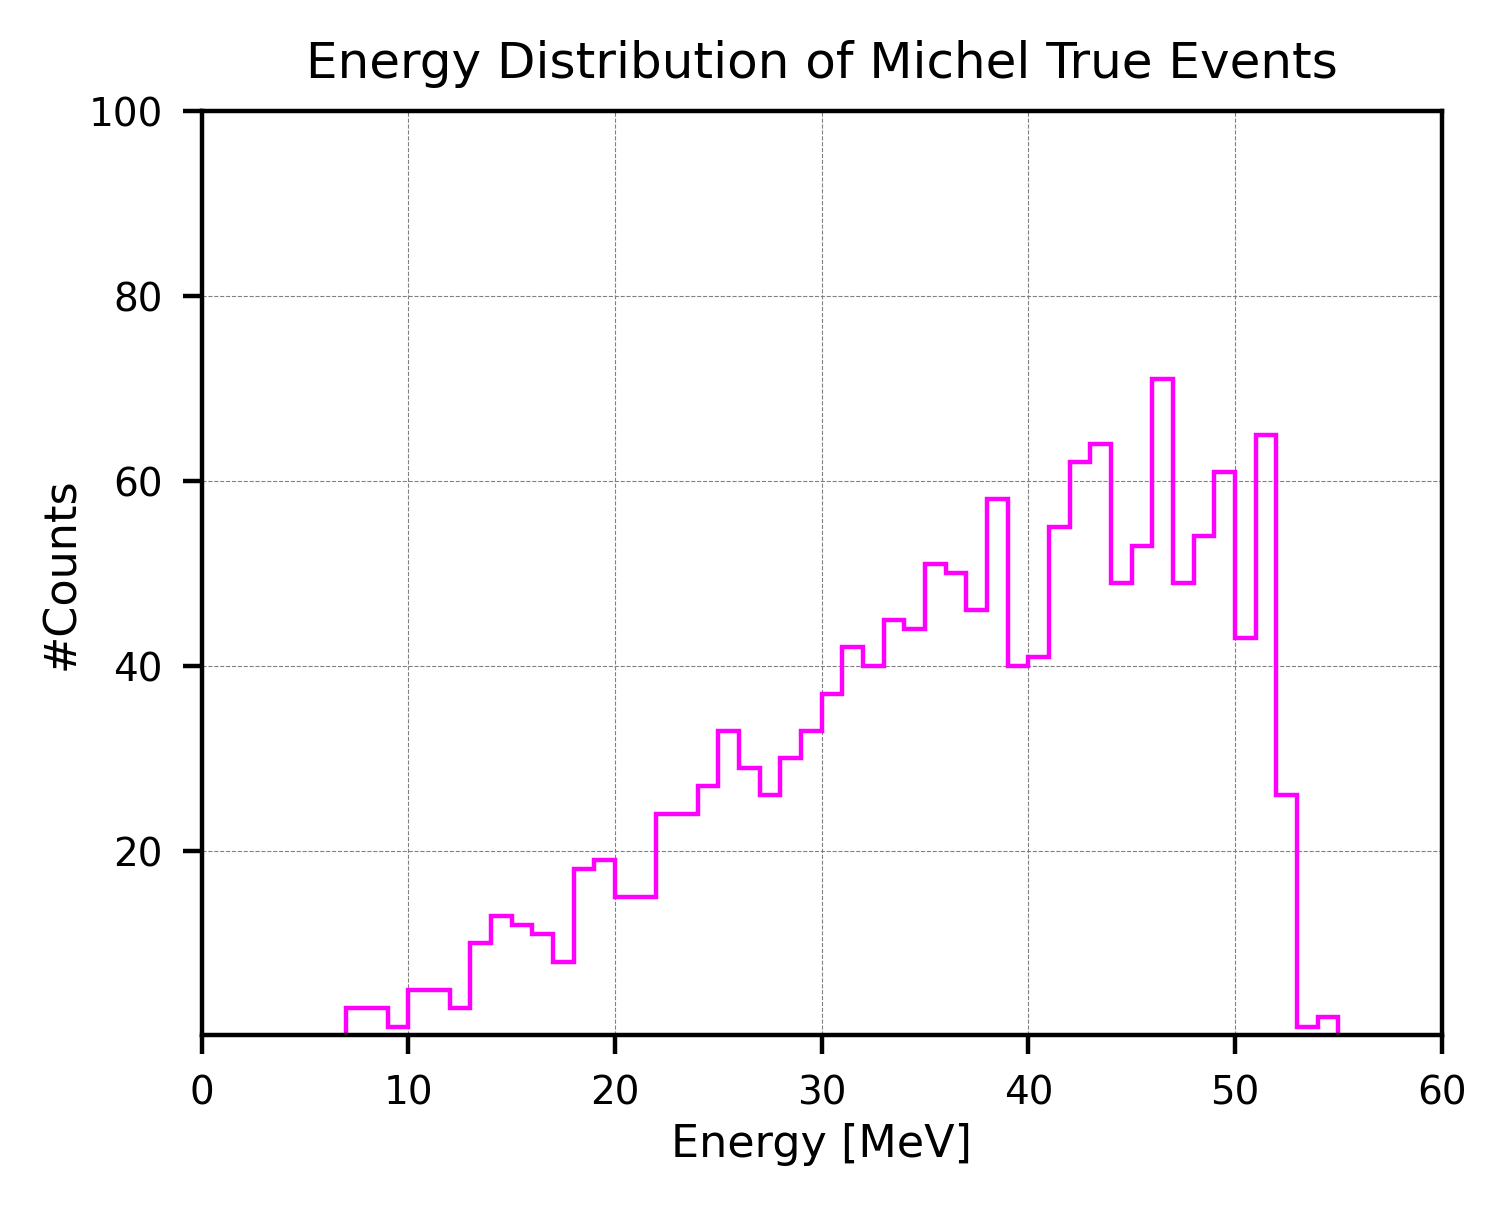

In [89]:

energyDis = [ev.energy for ev in true_newClass]


# Seperate Michel e^- and e^+------------------------------
life_positron = []
life_electron = []

for ev in true_newClass:
    pdg = ev.pdg
    life = ev.true_lifetime / 1000.0 # in unit of us---

    if pdg < 0:
        life_positron.append(life)
    elif pdg > 0:
        life_electron.append(life)

print("\nMichel e^+: ", len(life_positron), "/", len(true_newClass), 
      "({:.2f}%)".format(len(life_positron)/len(true_newClass)*100))
print("Michel e^-: ", len(life_electron), "/", len(true_newClass), 
      "({:.2f}%)".format(len(life_electron)/len(true_newClass)*100))
print("#e^+ / #e^-: ", len(life_positron), "/", len(life_electron),
      "({:.2f})".format(len(life_positron)/len(life_electron)))



#Fitting seperating for Michel e^+ and e^-=============================================================

# --- single exponential ---
def exp1(t, N, tau):
    return N * np.exp(-t / tau)

# --- plotting / binning setup ---
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.5
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- helper: weighted fit (σ = sqrt(y)), skip zeros, draw ---
def fit_and_draw(sample, label_prefix, fit_range=(0.05, 10)):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # choose fit window & drop zero bins
    m = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    x_all = bin_centers[m]
    y_all = counts[m]
    nz = y_all > 0
    x_fit = x_all[nz]
    y_fit = y_all[nz]

    # abort gracefully if too few points
    if len(y_fit) < 3:
        plt.hist(sample, bins=bins, range=(range_min, range_max),
                 histtype='step', linewidth=0.8, label=f"{label_prefix} MC data")
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    sigma = np.sqrt(y_fit)

    # safe initial guesses & bounds
    N0, tau0 = float(np.max(y_fit)), 2.0
    bounds = ([0.0, 1e-6], [np.inf, np.inf])

    # weighted least squares
    popt, pcov = curve_fit(
        exp1, x_fit, y_fit, p0=[N0, tau0],
        sigma=sigma, absolute_sigma=True,
        bounds=bounds, maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi2/ndf
    y_mod = exp1(x_fit, *popt)
    r = (y_fit - y_mod) / sigma
    chi2 = float(np.sum(r**2))
    ndf = max(len(x_fit) - len(popt), 1)
    chi2_ndf = chi2 / ndf

    # smooth curve
    x_smooth = np.linspace(fit_range[0], fit_range[1], 500)
    y_smooth = exp1(x_smooth, *popt)

    # draw histogram (step)
    plt.hist(sample, bins=bins, range=(range_min, range_max),
             histtype='step', linewidth=0.8, label=f"{label_prefix} data")

    # draw fit
    plt.plot(
        x_smooth, y_smooth,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
               + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    return (N_fit, tau_fit, N_err, tau_err, chi2_ndf)

# ---- run for both lists ----
N_p, tau_p, dN_p, dtau_p, chi2ndf_p = fit_and_draw(np.asarray(life_positron), "e⁺")
N_n, tau_n, dN_n, dtau_n, chi2ndf_n = fit_and_draw(np.asarray(life_electron), "e⁻")

# --- final plot cosmetics (kept similar to your style) ---
plt.xlim(-2, 18)
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distributions: Michel $e^+$ vs $e^-$', fontsize=9)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 8})
plt.tight_layout()
plt.show()







#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

final_trueE = [ev.energy for ev in true_newClass]
plt.hist(final_trueE, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 100)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  





### Lifetime VS energy:

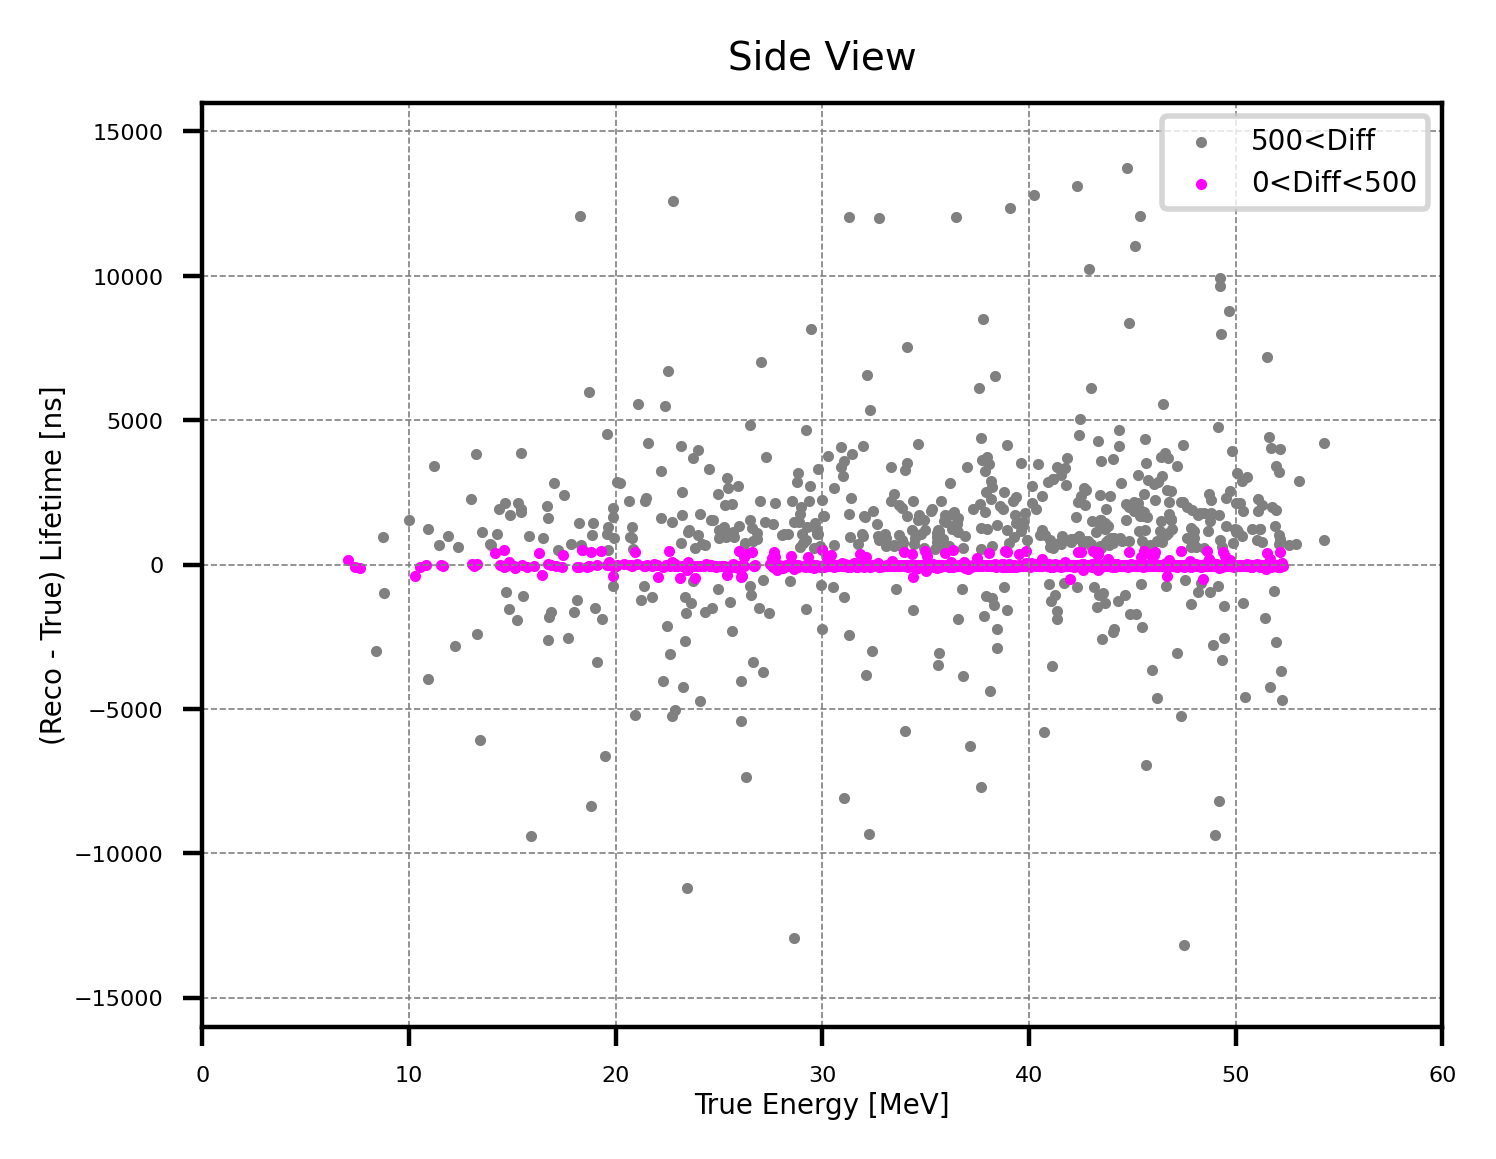

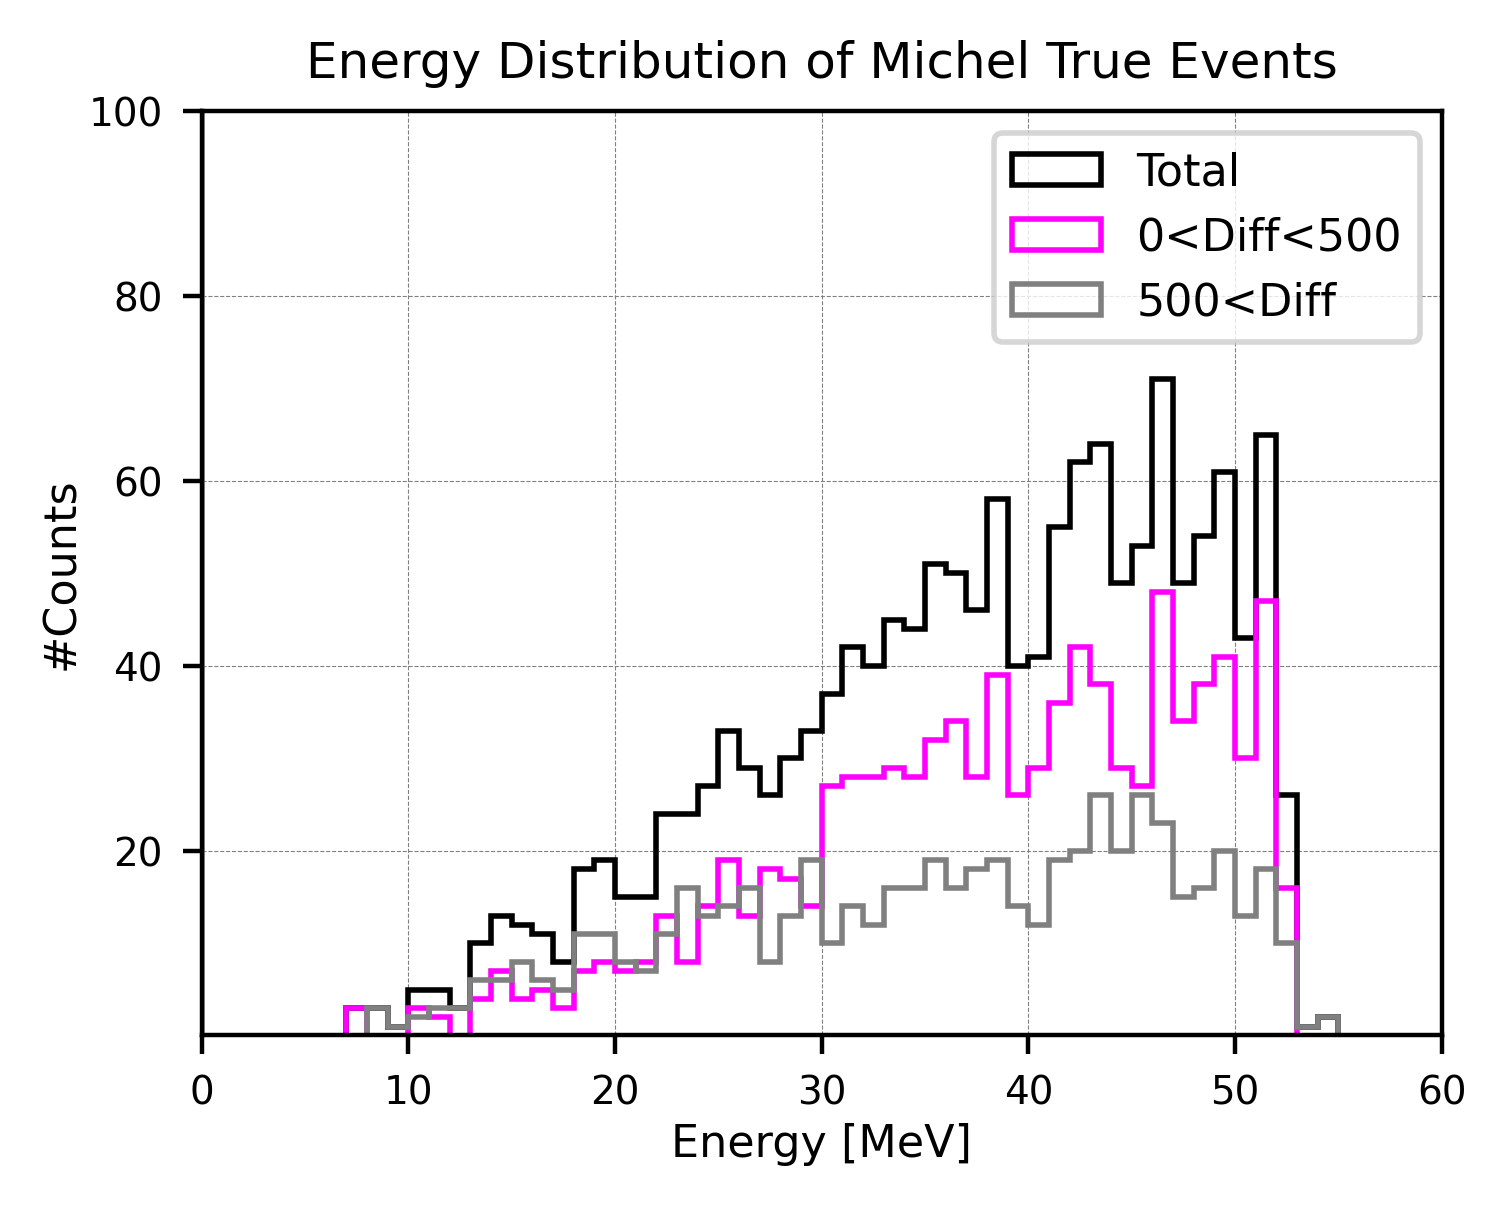

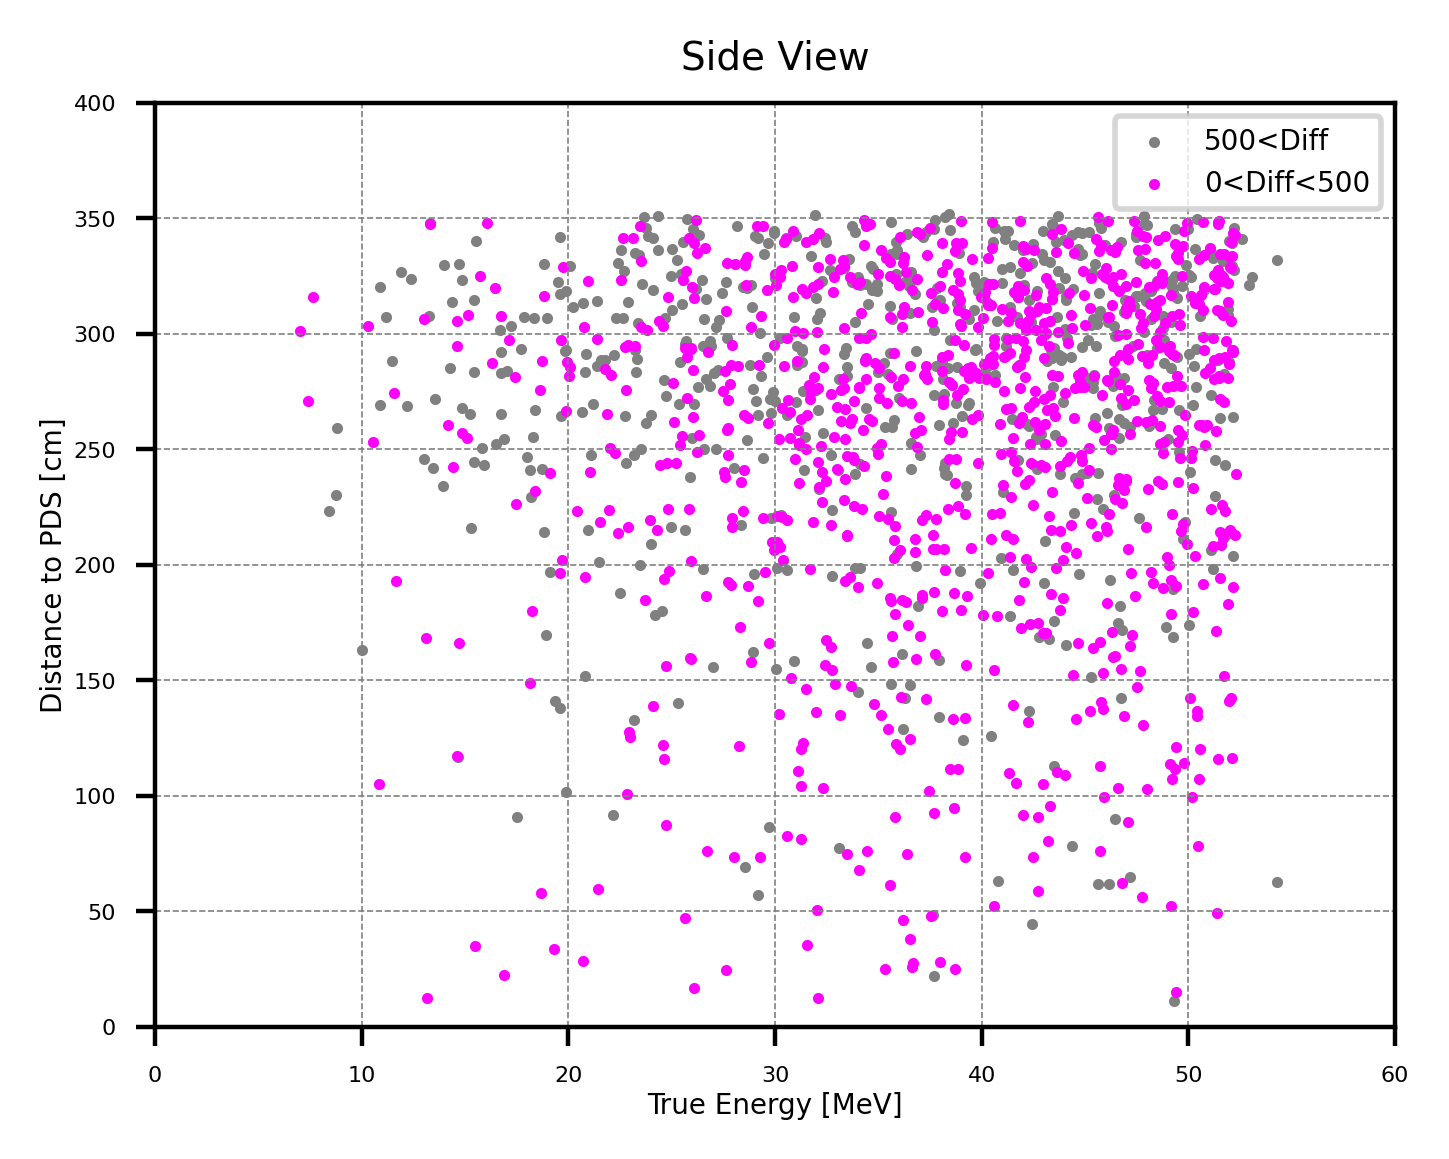

In [104]:

energy_diff500 = [ev.energy for ev in events_diff500]
trueL_diff500 = [ev.true_lifetime for ev in events_diff500]
recoL_diff500 = [ev.reco_lifetime for ev in events_diff500]
diffL_diff500 = [ev.diff_lifetime for ev in events_diff500]

distance_diff500 = [356 - abs(x) for x in posX_diff500]


energy_diff0 = [ev.energy for ev in events_diff0]
trueL_diff0 = [ev.true_lifetime for ev in events_diff0]
recoL_diff0 = [ev.reco_lifetime for ev in events_diff0]
diffL_diff0 = [ev.diff_lifetime for ev in events_diff0]

distance_diff0 = [356 - abs(x) for x in posX_diff0]



# ==========================================================
# Energy VS Lifetime
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)


# Scatter plot----------
plt.scatter(energy_diff500, diffL_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(energy_diff0, diffL_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

#plt.axis('scaled')
plt.ylim(-16000, 16000)
plt.xlim(0, 60)
plt.ylabel('(Reco - True) Lifetime [ns]', labelpad=1, fontsize=5)
plt.xlabel('True Energy [MeV]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

final_trueE = [ev.energy for ev in true_newClass]
plt.hist(final_trueE, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=1.0, label="Total")
plt.hist(energy_diff0, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="0<Diff<500")
plt.hist(energy_diff500, bins=bins, range=(range_min, range_max), edgecolor='grey', 
         histtype='step', linewidth=1.0, label="500<Diff")

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 100)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  







# ==========================================================
# Energy VS Distance
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)


# Scatter plot----------
plt.scatter(energy_diff500, distance_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(energy_diff0, distance_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

#plt.axis('scaled')
plt.ylim(0, 400)
plt.xlim(0, 60)
plt.ylabel('Distance to PDS [cm]', labelpad=1, fontsize=5)
plt.xlabel('True Energy [MeV]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()
